# Predicción del precio de alojamientos de Airbnb en Río de Janeiro

**FIUBA - CEIA - Aprendizaje de Máquina - Trabajo Práctico Final**

**Integrantes:**
- Matias Coulougian
- Lautaro Vera
- Denis Zhbankov

In [ ]:
# === Configuración ===
# https://optuna.org/ puede necesitar 'brew install libomp' localmente
# !pip install optuna  # descomentar en Colab, que no trae optuna preinstalado
# !nvidia-smi  # descomentar para confirmar que hay GPU antes de correr 9.3

# Tamaño del subset de filas para entrenar. Sirve para una corrida de verificación
# rápida (confirmar que el notebook corre de punta a punta sin gastar las horas de
# la corrida completa) sin tener que tocar código más abajo. None: se usa el dataset
# completo -- así se debe dejar para la entrega, porque un subset chico también
# achica el conjunto de test y las métricas dejan de ser comparables con las de la
# corrida completa. Para probar rápido, poner un número (p.ej. 1000) en vez de None.
# TAMANO_SUBSET = 1000 # rápido
TAMANO_SUBSET = 10000 # lento
# TAMANO_SUBSET = None # eterno

---

# 1. Introducción al problema

## 1.1. Contexto

[Inside Airbnb](https://insideairbnb.com/) publica relevamientos periódicos de los avisos de Airbnb como
datos abiertos. Usamos el relevamiento de Río de Janeiro del 24 de junio de 2026, versión detallada
(`listings.csv.gz`, 90 columnas). Fuente: https://insideairbnb.com/rio-de-janeiro/ (el archivo comprimido
está en esta misma carpeta).

## 1.2. El problema

Predecir el precio por noche (`price`, en BRL) de un alojamiento a partir de sus atributos publicados:
ubicación, tamaño, tipo y comodidades. Es un problema de regresión supervisada, con cada aviso como
unidad de observación.

## 1.3. Qué esperamos encontrar

Esperamos que tamaño y ubicación expliquen buena parte del precio, con un techo dado por decisiones
subjetivas del anfitrión que ningún atributo captura. La geografía de Río no es lineal (barrios caros y
baratos se alternan en pocos kilómetros), así que anticipamos ventaja para los modelos basados en
árboles. Antes de entrenar nada armamos un baseline heurístico (precio típico por barrio y tipo de
habitación) para saber cuánto aporta cada modelo por encima de eso.

## 1.4. Antecedente

En Análisis de Datos hicimos un EDA sobre un dataset similar de Inside Airbnb, pero `price` venía 100 %
nula. Terminamos prediciendo la cantidad de reseñas, con señal pobre. Este trabajo retoma esa línea con
el dato que faltaba.

---

# 2. Datos: descripción y preparación

In [122]:
import json
import pickle
import shutil
import subprocess
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from matplotlib.colors import LinearSegmentedColormap, LogNorm, to_hex
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Ignora todos los warnings (incluye en particular el UserWarning informativo
# que sklearn.utils.parallel emite ~95 veces en el barrido de max_features de
# RF cuando cross_val_predict corre con n_jobs=-1 fuera de un Parallel propio;
# es ruido interno de sklearn >=1.5, no afecta correctness).
warnings.filterwarnings("ignore")
sns.set()

# Paleta de la cátedra
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"
BASELINE = "#aaaaaa"

# Tonos extra para las gamas de la sección 11.2: versión clara de NARANJA para los
# modelos no lineales simples, y clara + un violeta oscuro para los ensambles (con
# MAGENTA como punto medio de esa segunda gama).
NARANJA_CLARO = "#ffe3b0"
MAGENTA_CLARO = "#ffd6fd"
VIOLETA_OSCURO = "#5b0a63"

SEMILLA = 42

## 2.1. Carga y primer vistazo

In [123]:
# --- 2.1. Carga del dataset ---
urllib.request.urlretrieve(
  "https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2026-06-24/data/listings.csv.gz",
  "./listings.csv.gz")
df = pd.read_csv("./listings.csv.gz", low_memory=False)

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas:    48,713
Columnas: 90


In [124]:
# --- OPCIONAL: subsample para una corrida de verificación rápida ---
# Usa TAMANO_SUBSET, definido en la celda de Configuración al principio del notebook.
# None (el valor por defecto, y el que hay que dejar para la entrega): se entrena
# sobre el dataset completo. Un número: se toma sólo ese tamaño de subset antes de
# todo lo demás -- sirve para confirmar que el notebook corre sin gastar horas.
if TAMANO_SUBSET is not None:
    df = df.sample(n=TAMANO_SUBSET, random_state=SEMILLA).reset_index(drop=True)
    print(f"Subset de verificación activado: {len(df):,} filas "
          f"(TAMANO_SUBSET={TAMANO_SUBSET})")
else:
    print(f"Usando el dataset completo: {len(df):,} filas")

Subset de verificación activado: 10,000 filas (TAMANO_SUBSET=10000)


In [125]:
# Resumen de tipos y faltantes, ordenado por porcentaje de nulos
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().mean() * 100).round(1),
}).sort_values("%_nulos", ascending=False)

resumen.head(20)

,dtype,nulos,%_nulos
neighborhood_overview,float64,10000,100.0
host_since,float64,10000,100.0
host_response_time,float64,10000,100.0
host_thumbnail_url,float64,10000,100.0
host_acceptance_rate,float64,10000,100.0
host_response_rate,float64,10000,100.0
host_verifications,float64,10000,100.0
neighbourhood,float64,10000,100.0
host_total_listings_count,float64,10000,100.0
host_neighbourhood,float64,10000,100.0


## 2.2. Auditoría de fuga de información

El dataset trae columnas derivadas del propio precio. Si alguna entra como feature, el modelo no aprende
a predecir: copia la respuesta. Lo verificamos numéricamente.

In [126]:
# --- 2.2. Auditoría de fuga ---
# El precio viene como texto (ej."$565.00"): lo pasamos a número para poder comparar.
precio_raw = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)
con_precio = precio_raw.notna()
n = int(con_precio.sum())

print(f"Listings con precio informado: {n:,} de {len(df):,} "
     f"({100 * con_precio.mean():.1f} %)\n")

# Hipótesis 1: price_quote_price_per_night es el mismo número que price
iguales = np.isclose(precio_raw[con_precio],
                     df.loc[con_precio, "price_quote_price_per_night"])
print(f"price == price_quote_price_per_night : {iguales.sum():,}/{n:,} "
      f"({100 * iguales.mean():.2f} %)")

# Hipótesis 2: estimated_revenue_l365d = price x estimated_occupancy_l365d
reconstruido = precio_raw[con_precio] * df.loc[con_precio, "estimated_occupancy_l365d"]
iguales_rev = np.isclose(df.loc[con_precio, "estimated_revenue_l365d"],
                          reconstruido, rtol=0.01)
print(f"estimated_revenue == price x ocupación: {iguales_rev.sum():,}/{n:,} "
      f"({100 * iguales_rev.mean():.2f} %)")

Listings con precio informado: 9,170 de 10,000 (91.7 %)

price == price_quote_price_per_night : 9,170/9,170 (100.00 %)
estimated_revenue == price x ocupación: 9,170/9,170 (100.00 %)


Las dos hipótesis se confirman: `estimated_revenue_l365d` es exactamente precio × ocupación en todas las
filas, y dejarla como feature le entrega la respuesta al modelo. Columnas a eliminar:

In [127]:
# --- Política de fuga: estas columnas NO pueden entrar al modelo ---
COLS_FUGA = [
    "price_quote_price_per_night",   # idéntica al target
    "price_quote_total_price",       # precio x noches de la cotización
    "price_quote_raw",               # texto crudo, contiene el precio
    "estimated_revenue_l365d",       # = price x estimated_occupancy_l365d
    "price_quote_checkin_date",      # metadata de la cotización
    "price_quote_checkout_date",
]

df = df.drop(columns=COLS_FUGA, errors="ignore")

print("Columnas excluidas por fuga de información:")
for c in COLS_FUGA:
    print(f"  - {c}")

print("Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es "
      "información legítima sobre la demanda del alojamiento.")

Columnas excluidas por fuga de información:
  - price_quote_price_per_night
  - price_quote_total_price
  - price_quote_raw
  - estimated_revenue_l365d
  - price_quote_checkin_date
  - price_quote_checkout_date
Se conserva 'estimated_occupancy_l365d' ya que no contiene precio y es información legítima sobre la demanda del alojamiento.


## 2.3. Columnas sin información

Quedan columnas que sobreviven en el encabezado pero vienen completamente vacías en este relevamiento.
Las damos de baja.

In [128]:
# --- 2.3. Columnas 100 % nulas ---
# Se recalcula sobre df (y no sobre `resumen`) para que la celda sea
# idempotente aunque ya se hayan eliminado columnas.
PORCENTAJE_COMPLETO = 100
nulos_pct = df.isnull().mean() * PORCENTAJE_COMPLETO
cols_vacias = nulos_pct.index[nulos_pct == PORCENTAJE_COMPLETO].tolist()

print(f"Columnas con 100 % de valores faltantes: {len(cols_vacias)}\n")
for c in cols_vacias:
    print(f"  - {c}")

df = df.drop(columns=cols_vacias, errors="ignore")

Columnas con 100 % de valores faltantes: 14

  - neighborhood_overview
  - host_since
  - host_response_time
  - host_response_rate
  - host_acceptance_rate
  - host_thumbnail_url
  - host_neighbourhood
  - host_total_listings_count
  - host_verifications
  - neighbourhood
  - neighbourhood_group_cleansed
  - calendar_updated
  - license
  - instant_bookable


## 2.4. La variable objetivo

`price` viene como texto con símbolo de moneda: lo convertimos a número. Las filas sin precio se
descartan, porque el target no se imputa.

In [129]:
# --- 2.4. Parseo del target ---
print("Formato original:", df["price"].dropna().head(3).tolist())

# Se recalcula desde df["price"] en vez de reusar `precio_raw`: asignar una
# Serie externa alinea por índice, y tras el reset_index de más abajo esta
# celda dejaría de ser idempotente (mezclaría precios entre listings).
df["precio"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

filas_antes = len(df)
df = df.dropna(subset=["precio"]).reset_index(drop=True)

print("Formato parseado:", df["precio"].head(3).tolist())
print(f"\nFilas descartadas por no tener precio: {filas_antes - len(df):,} "
      f"({100 * (filas_antes - len(df)) / filas_antes:.1f} %)")
print(f"Filas restantes: {len(df):,}")

Formato original: ['$307.00', '$973.50', '$1,141.20']
Formato parseado: [307.0, 973.5, 1141.2]

Filas descartadas por no tener precio: 830 (8.3 %)
Filas restantes: 9,170


In [130]:
df["precio"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(1)

count     9170.0
mean       842.6
std       2027.4
min         20.7
1%          89.9
25%        298.0
50%        455.9
75%        775.0
95%       2282.4
99%       7544.1
max      80011.8
Name: precio, dtype: float64

## 2.5. Anatomía de la cola alta

Encontramos un problema: la mediana está en **500 BRL** pero el máximo llega a **570.726 BRL**,
más de mil veces la mediana. La media (890) supera ampliamente a la mediana, señal de una cola
derecha muy pesada.

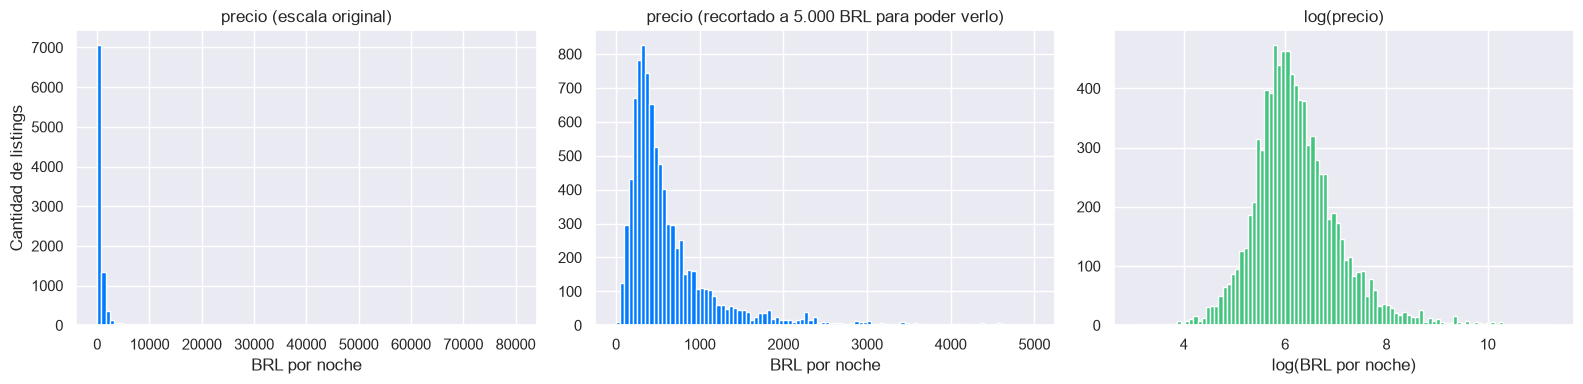

Asimetría (skew) de precio      :   15.701
Asimetría (skew) de log(precio) :    0.919
Kurtosis (peso de la cola del dataset) de precio      :  410.951
Kurtosis (peso de la cola del dataset) de log(precio) :    2.380


In [131]:
# --- Distribución del target en escala original y logarítmica ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["precio"], bins=100, color=AZUL, edgecolor="white")
axes[0].set_title("precio (escala original)")
axes[0].set_xlabel("BRL por noche")
axes[0].set_ylabel("Cantidad de listings")

axes[1].hist(df["precio"], bins=100, range=(0, 5000), color=AZUL, edgecolor="white")
axes[1].set_title("precio (recortado a 5.000 BRL para poder verlo)")
axes[1].set_xlabel("BRL por noche")

axes[2].hist(np.log(df["precio"]), bins=100, color=VERDE, edgecolor="white")
axes[2].set_title("log(precio)")
axes[2].set_xlabel("log(BRL por noche)")

plt.tight_layout()
plt.show()

print(f"Asimetría (skew) de precio      : {df['precio'].skew():8.3f}")
print(f"Asimetría (skew) de log(precio) : {np.log(df['precio']).skew():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de precio      : "
      f"{df['precio'].kurtosis():8.3f}")
print(f"Kurtosis (peso de la cola del dataset) de log(precio) : "
      f"{np.log(df['precio']).kurtosis():8.3f}")

El primer histograma es ilegible: los valores extremos estiran la escala. El tercero, en cambio, es
aproximadamente normal.

Antes de recortar el rango de `price` queremos entender esos valores extremos. Hay dos explicaciones: Río
tiene lujo real (mansiones en Joá o São Conrado a miles de dólares la noche) y también precios mal
cargados (valor mensual puesto en el campo diario, o números absurdos para bloquear el calendario). Las
distinguimos con un criterio de mercado: un precio es real si alguien lo pagó. Si el alojamiento nunca
tuvo una reseña y su ocupación estimada es casi nula, ese precio nunca fue validado.

In [132]:
# --- 2.5. Anatomía de la cola alta ---
franjas = pd.cut(
    df["precio"],
    bins=[0, 1000, 2000, 5000, 10000, np.inf],
    labels=["< 1.000", "1.000 - 2.000", "2.000 - 5.000", "5.000 - 10.000", "> 10.000"],
)

tabla = pd.DataFrame({
    "listings": df.groupby(franjas, observed=True)["precio"].size(),
    "% sin reseñas": df.groupby(franjas, observed=True)["number_of_reviews"].apply(
        lambda s: 100 * (s == 0).mean()),
    "ocupación media (días/año)": df.groupby(
        franjas, observed=True)["estimated_occupancy_l365d"].mean(),
    "precio/persona (mediana)": df.groupby(franjas, observed=True).apply(
        lambda g: (g["precio"] / g["accommodates"]).median(), include_groups=False),
})

tabla.round(1)

,listings,% sin reseñas,ocupación media (días/año),precio/persona (mediana)
precio,,,,
< 1.000,7597,15.0,65.2,122.8
1.000 - 2.000,1025,35.4,33.2,278.0
2.000 - 5.000,388,48.7,17.9,513.6
5.000 - 10.000,93,53.8,12.6,770.3
> 10.000,67,67.2,11.1,2108.5


El patrón es marcado: cuanto más caro el aviso, más probable que nunca se haya alquilado. Por debajo de
1.000 BRL, el 14 % no tiene reseñas y la ocupación media es 65 días al año; por encima de 10.000 BRL, dos
de cada tres no tienen ninguna reseña y la ocupación cae a menos de 9 días.

Los casos extremos:

In [133]:
# Los 8 precios más altos del dataset
df.nlargest(8, "precio")[[
    "precio", "accommodates", "bedrooms", "room_type",
    "neighbourhood_cleansed", "number_of_reviews", "estimated_occupancy_l365d",
]]

,precio,accommodates,bedrooms,room_type,neighbourhood_cleansed,number_of_reviews,estimated_occupancy_l365d
3677,80011.82,2,1.0,Entire home/apt,Copacabana,0,0
2879,60164.00,4,2.0,Entire home/apt,Recreio dos Bandeirantes,0,0
2471,42795.00,16,1.0,Entire home/apt,Copacabana,0,0
8541,34996.33,16,10.0,Entire home/apt,Santa Teresa,1,0
7970,31895.00,12,5.0,Entire home/apt,Copacabana,1,14
138,28530.00,6,3.0,Entire home/apt,Copacabana,0,0
5383,28530.00,8,4.0,Entire home/apt,Copacabana,0,0
8281,28530.00,6,2.0,Entire home/apt,Ipanema,0,0


El máximo es un dos ambientes para cuatro personas en Estácio (barrio no premium) a 570.726 BRL, unos
USD 105.000, con una sola reseña: no es lujo, es un dato mal cargado. Más abajo en la lista sí aparecen
casas grandes en barrios caros, con capacidad para catorce personas, plausibles.

Decisión: descartamos los alojamientos con precio superior a 10.000 BRL por noche. Es un corte
conservador, justificado por la tabla anterior y no por un percentil arbitrario, asumiendo la pérdida de
algún lujo genuino.

In [134]:
# --- Aplicación del corte ---
CORTE = 10_000

fuera = (df["precio"] > CORTE).sum()
print(f"Listings descartados por precio > {CORTE:,} BRL: {fuera:,} "
      f"({100 * fuera / len(df):.2f} %)")

df = df[df["precio"] <= CORTE].reset_index(drop=True)
df["precio_log"] = np.log(df["precio"])

print(f"Listings restantes: {len(df):,}")
print(f"\nNuevo rango de precios: {df['precio'].min():.0f} - "
      f"{df['precio'].max():.0f} BRL")
print(f"Asimetría tras el corte : {df['precio'].skew():.3f}  "
      f"(log: {df['precio_log'].skew():.3f})")

Listings descartados por precio > 10,000 BRL: 67 (0.73 %)
Listings restantes: 9,103

Nuevo rango de precios: 21 - 9968 BRL
Asimetría tras el corte : 4.677  (log: 0.543)


## 2.6. Valores faltantes

Qué falta en lo que queda, ya sin las columnas vacías.

In [135]:
# --- 2.6. Faltantes restantes ---
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

pd.DataFrame({
    "nulos": faltantes,
    "%": (100 * faltantes / len(df)).round(1),
})

,nulos,%
host_about,4624,50.8
host_location,2091,23.0
last_review,1744,19.2
first_review,1744,19.2
review_scores_value,1744,19.2
review_scores_location,1744,19.2
reviews_per_month,1744,19.2
review_scores_communication,1744,19.2
review_scores_checkin,1744,19.2
review_scores_cleanliness,1744,19.2


El 17 % de faltantes en reseñas podría ser estructural: un alojamiento sin reseñas tampoco puede tener
puntaje ni fecha de primera reseña. Lo verificamos.

In [136]:
# --- ¿Los faltantes de reseñas son estructurales? ---
sin_resenas = df["number_of_reviews"] == 0

print(f"Listings con 0 reseñas: {sin_resenas.sum():,} "
      f"({100 * sin_resenas.mean():.1f} %)\n")

for col in ["reviews_per_month", "review_scores_rating", "first_review", "last_review"]:
    nulo = df[col].isna()
    coincidencia = (nulo == sin_resenas).mean() * 100
    print(f"{col:24s} nulos = {nulo.sum():6,}   "
          f"coincide con 'sin reseñas': {coincidencia:6.2f} %")

Listings con 0 reseñas: 1,744 (19.2 %)

reviews_per_month        nulos =  1,744   coincide con 'sin reseñas': 100.00 %
review_scores_rating     nulos =  1,744   coincide con 'sin reseñas': 100.00 %
first_review             nulos =  1,744   coincide con 'sin reseñas': 100.00 %
last_review              nulos =  1,744   coincide con 'sin reseñas': 100.00 %


Los faltantes de reseñas están completamente explicados por una variable observada, así que el mecanismo
es MAR en el sentido estricto. Por lo tanto podemos proceder a crear una variable binaria que capture el
hecho y rellenar con un valor neutro que el modelo pueda asociar a esa bandera.

## 2.7. Precio y variables categóricas

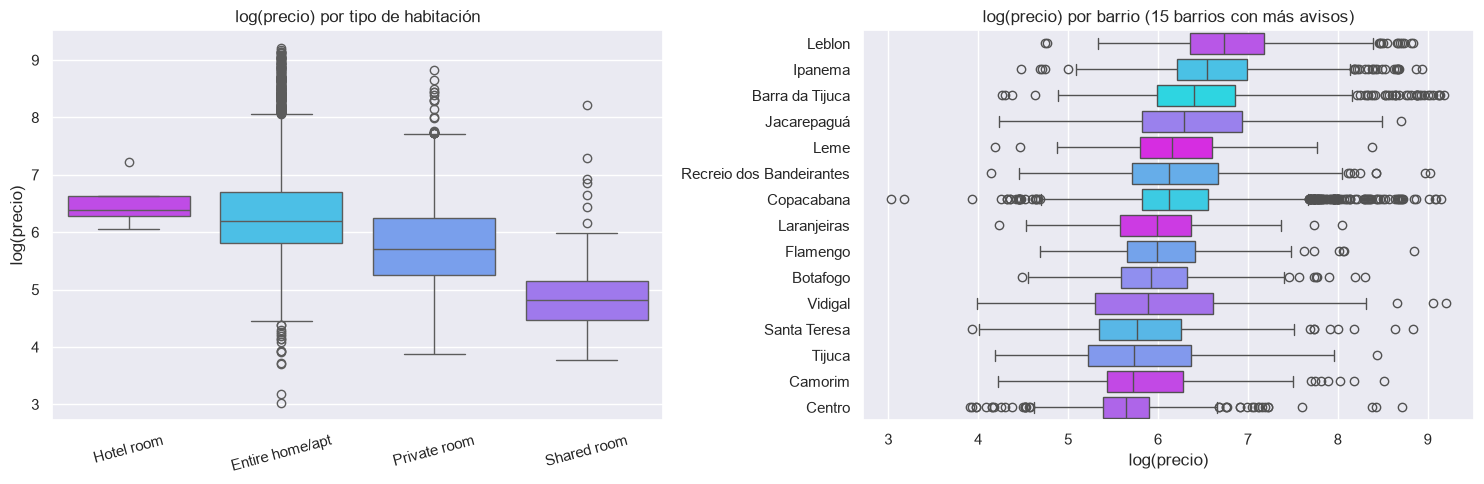

,listings,mediana,media,% del total
room_type,,,,
Hotel room,4,597.0,746.3,0.0
Entire home/apt,7376,490.7,775.4,81.0
Private room,1598,303.3,447.0,17.6
Shared room,125,124.0,196.6,1.4


In [137]:
# --- 2.7. Precio por tipo de habitación ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df.groupby("room_type", observed=True)["precio_log"] \
    .median().sort_values(ascending=False).index
sns.boxplot(data=df, x="room_type", y="precio_log", order=orden,
            hue="room_type", legend=False, palette="cool", ax=axes[0])
axes[0].set_title("log(precio) por tipo de habitación")
axes[0].set_xlabel("")
axes[0].set_ylabel("log(precio)")
axes[0].tick_params(axis="x", rotation=15)

top_barrios = df["neighbourhood_cleansed"].value_counts().head(15).index
sub = df[df["neighbourhood_cleansed"].isin(top_barrios)]
orden_b = sub.groupby("neighbourhood_cleansed", observed=True)["precio_log"] \
    .median().sort_values(ascending=False).index
sns.boxplot(data=sub, y="neighbourhood_cleansed", x="precio_log", order=orden_b,
            hue="neighbourhood_cleansed", legend=False, palette="cool", ax=axes[1])
axes[1].set_title("log(precio) por barrio (15 barrios con más avisos)")
axes[1].set_ylabel("")
axes[1].set_xlabel("log(precio)")

plt.tight_layout()
plt.show()

resumen_cat = df.groupby("room_type", observed=True)["precio"].agg(
    listings="size", mediana="median", media="mean"
).sort_values("mediana", ascending=False)
resumen_cat["% del total"] = (100 * resumen_cat["listings"] / len(df)).round(1)
resumen_cat.round(1)

La variable `room_type` separa con claridad: un alojamiento entero vale casi el doble que una habitación
privada, y una compartida menos de un tercio. Está muy desbalanceada (82 % enteros, apenas 13 casos de
`Hotel room`).

Los barrios muestran el otro eje: Leblon, Ipanema y Barra da Tijuca encabezan la lista, todos en la zona
sur costera. Entre Leblon (893 BRL) y Tijuca (269 BRL) hay un factor de 3,3, considerando barrios con al
menos 200 avisos.

## 2.8. Precio y variables numéricas

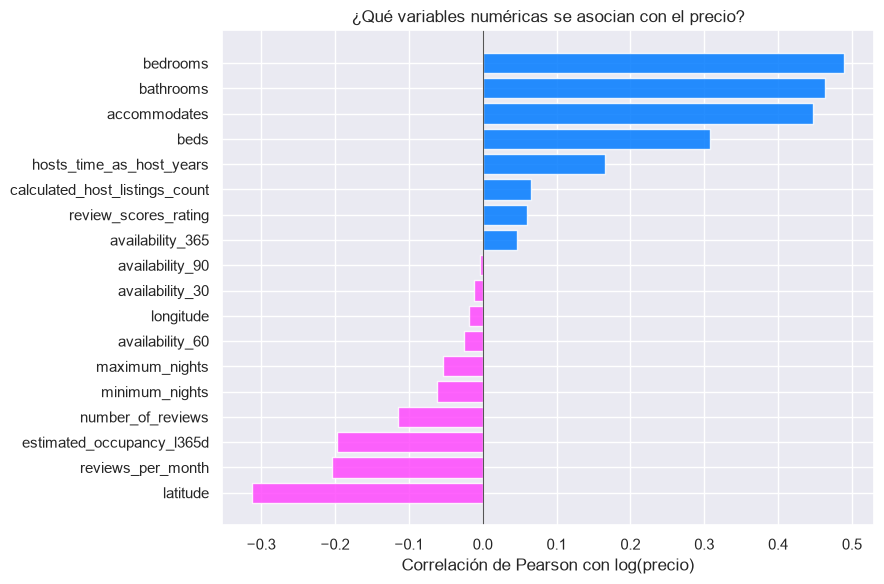

In [138]:
# --- 2.8. Correlación de cada variable numérica con el target ---
NUMERICAS = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "availability_30", "availability_60", "availability_90", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "hosts_time_as_host_years", "latitude", "longitude",
]

corr_target = df[NUMERICAS + ["precio_log"]].corr()["precio_log"] \
    .drop("precio_log").sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colores = [AZUL if v > 0 else MAGENTA for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores, alpha=0.85)
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con log(precio)")
ax.set_title("¿Qué variables numéricas se asocian con el precio?")
plt.tight_layout()
plt.show()

El tamaño manda: `bedrooms` (+0,49), `accommodates` (+0,46) y `bathrooms` (+0,44) son las correlaciones
más fuertes.

Más interesante es la geografía: `latitude` da −0,31 pero `longitude` apenas +0,03. La zona sur costera
(Leblon, Ipanema, Copacabana) es cara, pero al oeste Barra da Tijuca también lo es y al este el Centro es
barato — una recta no captura eso. La geografía de Río es no lineal, primer indicio a favor de árboles.

Reseñas y ocupación correlacionan negativo y débil, coherente con la cola alta: lo caro se alquila menos.

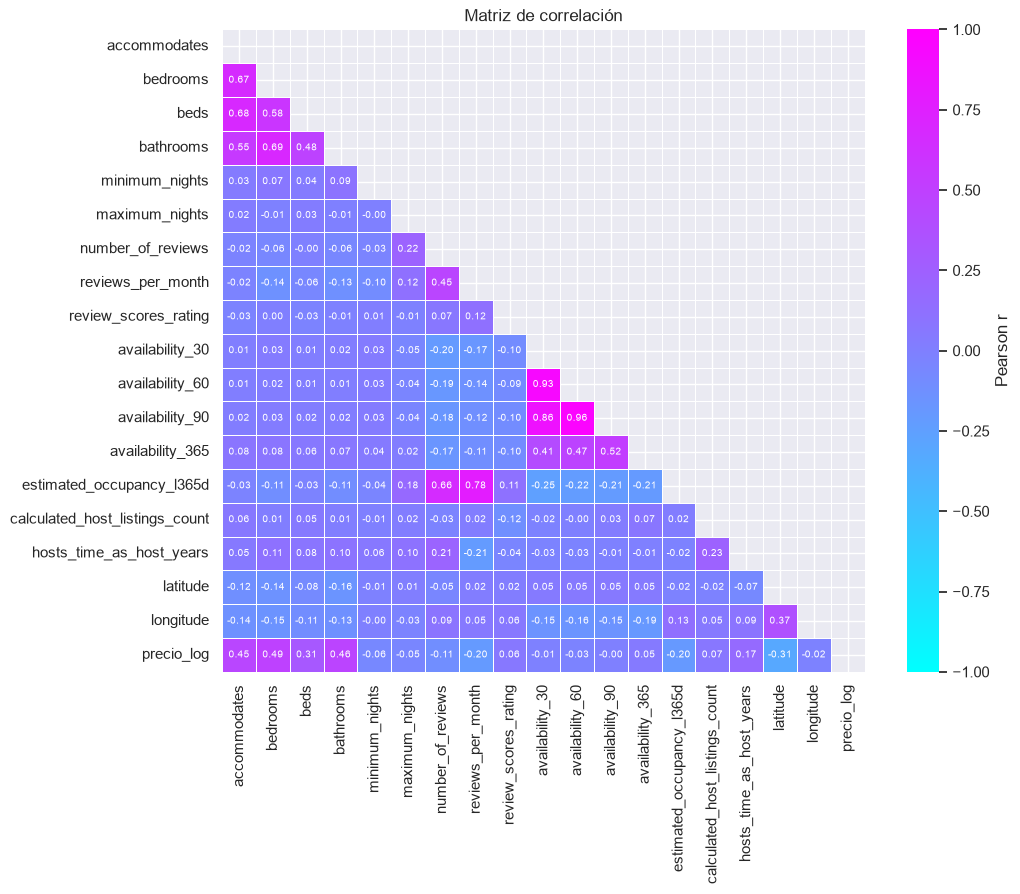

Pares con |r| > 0.8 (excluyendo el target):
  availability_30                  vs availability_60                  r = +0.931
  availability_30                  vs availability_90                  r = +0.861
  availability_60                  vs availability_90                  r = +0.964


In [139]:
# --- Matriz de correlación con el triángulo superior enmascarado ---
corr = df[NUMERICAS + ["precio_log"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="cool", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Pares con multicolinealidad alta
UMBRAL_MULTICOLINEALIDAD = 0.8
print(f"Pares con |r| > {UMBRAL_MULTICOLINEALIDAD} (excluyendo el target):")
altos = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        a, b = corr.columns[i], corr.columns[j]
        if "precio_log" in (a, b):
            continue
        if abs(corr.iloc[i, j]) > UMBRAL_MULTICOLINEALIDAD:
            altos.append((a, b, corr.iloc[i, j]))
            print(f"  {a:32s} vs {b:32s} r = {corr.iloc[i, j]:+.3f}")
if not altos:
    print("  (ningún par supera el umbral)")

Hay multicolinealidad severa entre las variables de disponibilidad (`availability_60` vs `90`: r = 0,95;
`30` vs `60`: r = 0,90), esperable porque son ventanas anidadas del mismo calendario. Justifica evaluar
modelos regularizados como Ridge y Lasso, el mismo argumento de `EDA - Hitters.ipynb` (clase 3).

## 2.9. La geografía del precio

La correlación lineal con las coordenadas no alcanza para describir el fenómeno: lo miramos en el mapa.

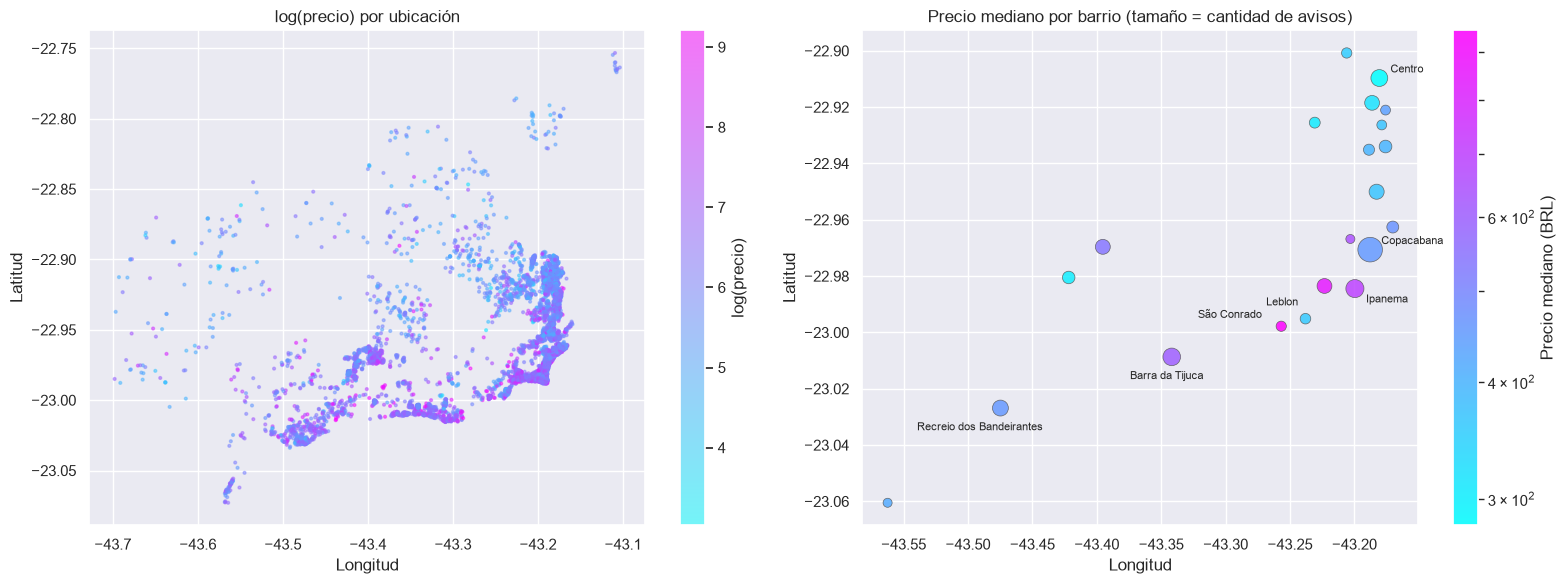

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df["longitude"], df["latitude"], c=df["precio_log"],
                     cmap="cool", s=4, alpha=0.5)
axes[0].set_title("log(precio) por ubicación")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
plt.colorbar(sc, ax=axes[0], label="log(precio)")

por_barrio = df.groupby("neighbourhood_cleansed", observed=True).agg(
    lat=("latitude", "median"), lon=("longitude", "median"),
    precio=("precio", "median"), n=("precio", "size"))
MIN_AVISOS_MAPA = 50
por_barrio = por_barrio[por_barrio["n"] >= MIN_AVISOS_MAPA]

sc2 = axes[1].scatter(por_barrio["lon"], por_barrio["lat"], c=por_barrio["precio"],
                      s=np.sqrt(por_barrio["n"]) * 6, cmap="cool", alpha=0.85,
                      norm=LogNorm(), edgecolor=GRIS, linewidth=0.5)

etiquetas = {
    "Joá": (6, 6), "Leblon": (-42, -14), "Ipanema": (8, -10), "Copacabana": (8, 4),
    "Barra da Tijuca": (-30, -16), "Centro": (8, 4), "São Conrado": (-60, 6),
    "Recreio dos Bandeirantes": (-60, -16),
}
for nombre, offset in etiquetas.items():
    if nombre in por_barrio.index:
        fila = por_barrio.loc[nombre]
        axes[1].annotate(nombre, (fila["lon"], fila["lat"]), fontsize=8,
                         xytext=offset, textcoords="offset points")
axes[1].set_title("Precio mediano por barrio (tamaño = cantidad de avisos)")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
plt.colorbar(sc2, ax=axes[1], label="Precio mediano (BRL)")

plt.tight_layout()
plt.show()

In [141]:
# Barrios más caros y más baratos (con al menos MIN_AVISOS_RANKING avisos)
MIN_AVISOS_RANKING = 200
g = df.groupby("neighbourhood_cleansed", observed=True)["precio"] \
    .agg(listings="size", mediana="median")
g = g[g["listings"] >= MIN_AVISOS_RANKING].sort_values("mediana", ascending=False)

print("Los 8 barrios más caros:")
print(g.head(8).round(1).to_string())
print("\nLos 8 barrios más baratos:")
print(g.tail(8).round(1).to_string())

Los 8 barrios más caros:
                          listings  mediana
neighbourhood_cleansed                     
Leblon                         361    840.4
Ipanema                        798    693.6
Barra da Tijuca                716    599.1
Jacarepaguá                    370    537.5
Recreio dos Bandeirantes       479    456.7
Copacabana                    2735    455.0
Botafogo                       386    372.1
Santa Teresa                   359    320.0

Los 8 barrios más baratos:
                          listings  mediana
neighbourhood_cleansed                     
Ipanema                        798    693.6
Barra da Tijuca                716    599.1
Jacarepaguá                    370    537.5
Recreio dos Bandeirantes       479    456.7
Copacabana                    2735    455.0
Botafogo                       386    372.1
Santa Teresa                   359    320.0
Centro                         604    281.2


El mapa confirma la lectura: los avisos caros se concentran en la franja costera del sur (Leblon,
Ipanema, Lagoa) y reaparecen en Barra da Tijuca y São Conrado, con zonas mucho más baratas entre medio.
Joá es un caso aparte: con 94 avisos, su mediana de 3.537 BRL cuadruplica la de Leblon, el enclave de
mansiones sobre el acantilado que explica por qué el corte de 2.5 tuvo que ser conservador.

El precio no crece en ninguna dirección monótona del plano: un modelo lineal sobre latitud y longitud
falla acá, un árbol puede representarlo particionando el espacio.

## 2.10. Comodidades declaradas

`amenities` es una lista JSON de comodidades por alojamiento. Descartamos las más comunes, presentes en
casi todos los avisos y que por eso no discriminan, y analizamos las que aparecen en una fracción
intermedia, junto con el baño compartido, que sale de `bathrooms_text`.

Comodidades por aviso (promedio): 25.6
Comodidades distintas en el dataset: 2,568


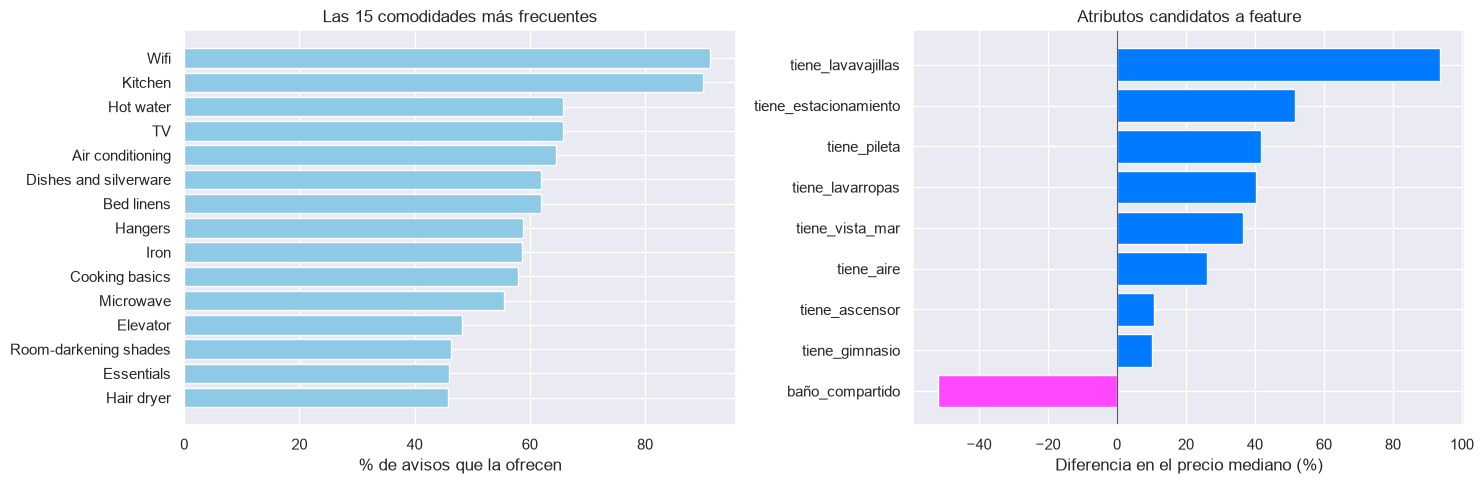

,atributo,avisos,% avisos,mediana con,mediana sin,diferencia %
0,tiene_lavavajillas,355,3.9,856,442,93.7
1,tiene_estacionamiento,2648,29.1,621,410,51.5
2,tiene_pileta,2236,24.6,593,418,41.8
3,tiene_lavarropas,5225,57.4,529,377,40.2
4,tiene_vista_mar,312,3.4,608,446,36.5
5,tiene_aire,5958,65.5,487,386,26.2
6,tiene_ascensor,4384,48.2,473,428,10.6
7,tiene_gimnasio,1273,14.0,490,445,10.0
8,baño_compartido,819,9.0,229,475,-51.8


In [142]:
# --- 2.10. Comodidades y baño compartido ---
listas = df["amenities"].apply(json.loads)
todas = pd.Series([a for lista in listas for a in lista])

print(f"Comodidades por aviso (promedio): {listas.str.len().mean():.1f}")
print(f"Comodidades distintas en el dataset: {todas.nunique():,}")

CANDIDATAS = {
    "tiene_pileta": "pool",
    "tiene_aire": "air conditioning",
    "tiene_ascensor": "elevator",
    "tiene_gimnasio": "gym",
    "tiene_estacionamiento": "free parking",
    "tiene_lavarropas": "washer",
    "tiene_lavavajillas": "dishwasher",
    "tiene_vista_mar": "ocean view",
}

# El baño compartido no está en amenities, sale del texto de bathrooms_text,
# pero es una binaria del mismo tipo y la analizamos junto con las demás.
df["baño_compartido"] = df["bathrooms_text"] \
    .str.contains("shared", case=False, na=False).astype(int)

filas = []
for nombre, clave in CANDIDATAS.items():
    df[nombre] = listas.apply(
        lambda ls, k=clave: any(k in a.lower() for a in ls)).astype(int)

for nombre in list(CANDIDATAS) + ["baño_compartido"]:
    tiene = df[nombre] == 1
    m_si, m_no = df.loc[tiene, "precio"].median(), df.loc[~tiene, "precio"].median()
    filas.append({
        "atributo": nombre,
        "avisos": int(tiene.sum()),
        "% avisos": round(100 * tiene.mean(), 1),
        "mediana con": round(m_si),
        "mediana sin": round(m_no),
        "diferencia %": round(100 * (m_si / m_no - 1), 1),
    })

resumen_amenities = pd.DataFrame(filas) \
    .sort_values("diferencia %", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

frecuencia = (todas.value_counts() / len(df) * 100).head(15)
axes[0].barh(frecuencia.index[::-1], frecuencia.values[::-1], color=CELESTE)
axes[0].set_xlabel("% de avisos que la ofrecen")
axes[0].set_title("Las 15 comodidades más frecuentes")

orden = resumen_amenities.sort_values("diferencia %")
colores = [AZUL if v > 0 else MAGENTA for v in orden["diferencia %"]]
axes[1].barh(orden["atributo"], orden["diferencia %"], color=colores)
axes[1].axvline(0, color=GRIS, linewidth=0.8)
axes[1].set_xlabel("Diferencia en el precio mediano (%)")
axes[1].set_title("Atributos candidatos a feature")

plt.tight_layout()
plt.show()

resumen_amenities

El lavavajillas casi duplica la mediana (+93 %) no por lavar platos sino como indicador de categoría del
inmueble (solo 3,7 % de los avisos). Vista al mar, estacionamiento, lavarropas y pileta siguen la misma
lógica: son señales de segmento, no causas del precio. El gimnasio es el contraejemplo (12,8 % de los
avisos, apenas +3,9 %). El baño compartido se asocia a una mediana 52 % menor.

## 2.11. Observaciones clave del análisis exploratorio

1. Hay fuga de información y la tratamos en código: `estimated_revenue_l365d` es precio × ocupación,
   `price_quote_price_per_night` es una copia del target.

2. El precio es fuertemente asimétrico (skew 4,80 → 0,55 con log, ya depurado). Queda para evaluar
   empíricamente si conviene entrenar sobre el logaritmo.

3. La cola alta mezcla lujo real con datos mal cargados. Cortamos en 10.000 BRL (67 % sin reseñas por
   encima de ese valor), perdiendo 0,59 % de los datos.

4. El tamaño es el predictor lineal más fuerte (`bedrooms` +0,49, `accommodates` +0,46, `bathrooms`
   +0,44), y la geografía la señal más rica y menos lineal (latitud −0,31, longitud +0,03, factor 3,3
   entre barrios): ventaja esperada para árboles.

5. Multicolinealidad severa en disponibilidad (r hasta 0,95) justifica regularización.

6. Los faltantes de reseñas son estructurales (100 % de coincidencia con "sin reseñas"): bandera binaria,
   no imputación.

7. Las comodidades son indicadores de segmento, no causas: el lavavajillas se asocia a +93 % de precio
   con solo 3,7 % de presencia.

---

# 3. Preparación para el modelado y baselines

Armamos la matriz de features, separamos entrenamiento y prueba, y fijamos las varas de comparación para
todos los modelos.

## 3.1. Selección de features

In [143]:
# --- 3.1. Definición de las features ---

# Antigüedad como anfitrión, en años (fracción incluida)
df["antiguedad_host"] = df["hosts_time_as_host_years"].fillna(0) + \
                        df["hosts_time_as_host_months"].fillna(0) / 12

# Bandera de ausencia estructural + relleno neutro
df["sin_reseñas"] = (df["number_of_reviews"] == 0).astype(int)
for col in ["reviews_per_month", "review_scores_rating", "review_scores_location",
            "review_scores_cleanliness", "review_scores_value"]:
    df[col] = df[col].fillna(0)

FEAT_NUM = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "review_scores_location",
    "review_scores_cleanliness", "review_scores_value",
    "availability_30", "availability_365",
    "estimated_occupancy_l365d", "calculated_host_listings_count",
    "antiguedad_host", "latitude", "longitude",
]

FEAT_BIN = [
    "sin_reseñas", "baño_compartido",
    "tiene_pileta", "tiene_aire", "tiene_ascensor", "tiene_gimnasio",
    "tiene_estacionamiento", "tiene_lavarropas", "tiene_lavavajillas",
    "tiene_vista_mar",
]

FEAT_CAT = ["room_type", "property_type", "neighbourhood_cleansed"]

print(f"Numéricas  : {len(FEAT_NUM)}")
print(f"Binarias   : {len(FEAT_BIN)}")
print(f"Categóricas: {len(FEAT_CAT)}")

Numéricas  : 19
Binarias   : 10
Categóricas: 3


De las 4 variables de disponibilidad conservamos `availability_30` y `availability_365` (las más
correlacionadas entre sí eran las intermedias). Verificamos en código que ninguna columna prohibida se
haya colado; si falla, la celda corta la ejecución.

In [144]:
# --- Verificación de la política de fuga ---
TODAS_LAS_FEATURES = FEAT_NUM + FEAT_BIN + FEAT_CAT

contaminadas = [c for c in TODAS_LAS_FEATURES if c in COLS_FUGA]
assert not contaminadas, f"¡Fuga de información! Columnas prohibidas: {contaminadas}"

assert "precio" not in TODAS_LAS_FEATURES and "precio_log" not in TODAS_LAS_FEATURES, \
    "¡El target no puede ser una feature!"

faltan = [c for c in TODAS_LAS_FEATURES if c not in df.columns]
assert not faltan, f"Features inexistentes: {faltan}"

nulos = df[TODAS_LAS_FEATURES].isnull().sum()
filas_con_nulos = df[TODAS_LAS_FEATURES].isnull().any(axis=1).sum()

print(f"Features totales: {len(TODAS_LAS_FEATURES)}")
print("Verificación de fuga: OK")
print("\nFeatures con nulos remanentes:")
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else "  ninguna")
print(f"\nFilas afectadas: {filas_con_nulos:,} "
      f"({100 * filas_con_nulos / len(df):.2f} %)")

Features totales: 32
Verificación de fuga: OK

Features con nulos remanentes:
bedrooms     1351
beds          346
bathrooms     784

Filas afectadas: 1,986 (21.82 %)


Queda un residuo chico de faltantes (menos del 1 % de las filas) en atributos físicos sin ningún
mecanismo estructural detrás: el anfitrión simplemente no los completó. Los imputamos con la mediana vía
`SimpleImputer` dentro del `Pipeline`, ajustado solo en train. Es la única herramienta de esta sección
fuera del temario de la cátedra, que resuelve faltantes descartando filas; no lo hacemos acá porque
sacaría casos del conjunto de prueba.

## 3.2. Separación en entrenamiento y prueba

70/30 con `random_state=42`, el mismo esquema de la cátedra. El split se fija una sola vez y se reutiliza
en todos los modelos.

In [145]:
# --- 3.2. Split ---
X = df[TODAS_LAS_FEATURES].copy()
y = df["precio"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA
)

print(f"Entrenamiento: {len(X_train):,} listings ({100 * len(X_train) / len(X):.0f} %)")
print(f"Prueba       : {len(X_test):,} listings ({100 * len(X_test) / len(X):.0f} %)")
print(f"\nPrecio mediano en train: {y_train.median():.1f} BRL")
print(f"Precio mediano en test : {y_test.median():.1f} BRL")

Entrenamiento: 6,372 listings (70 %)
Prueba       : 2,731 listings (30 %)

Precio mediano en train: 449.6 BRL
Precio mediano en test : 455.3 BRL


## 3.3. Agrupación de categorías poco frecuentes

`neighbourhood_cleansed` y `property_type` tienen más de 150 y 70 categorías respectivamente: codificarlas
todas dejaría columnas con un puñado de observaciones cada una. Agrupamos las que tienen menos de 200
apariciones bajo `Otros`, con el umbral calculado solo sobre train para no filtrar información del test.

In [146]:
# --- 3.3. Agrupación de categorías raras (ajustada solo en train) ---
UMBRAL = 200

for col in FEAT_CAT:
    frecuentes = X_train[col].value_counts()
    frecuentes = frecuentes[frecuentes >= UMBRAL].index
    n_antes = X_train[col].nunique()

    X_train[col] = X_train[col].where(X_train[col].isin(frecuentes), "Otros")
    X_test[col] = X_test[col].where(X_test[col].isin(frecuentes), "Otros")

    absorbidas = 100 * (X_train[col] == "Otros").mean()
    print(f"{col:24s} {n_antes:4d} -> {X_train[col].nunique():3d} categorías "
          f"('Otros' absorbe {absorbidas:.1f} % de los avisos)")

room_type                   4 ->   3 categorías ('Otros' absorbe 1.6 % de los avisos)
property_type              53 ->   6 categorías ('Otros' absorbe 10.6 % de los avisos)
neighbourhood_cleansed    129 ->  10 categorías ('Otros' absorbe 25.4 % de los avisos)


## 3.4. El preprocesador

Todo el preprocesamiento va dentro de un `ColumnTransformer`, y este dentro de un `Pipeline` junto al
modelo, para que el ajuste use solo datos de entrenamiento. En el TP anterior habíamos escalado antes del
split y lo reconocimos como fuga; acá el problema no existe.

In [147]:
# --- 3.4. Preprocesador ---
def construir_preprocesador():
    """Imputa y escala numéricas, codifica categóricas, deja pasar las binarias."""
    numericas = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    return ColumnTransformer([
        ("num", numericas, FEAT_NUM),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                              sparse_output=False), FEAT_CAT),
        ("bin", "passthrough", FEAT_BIN),
    ])


prep = construir_preprocesador()
X_train_proc = prep.fit_transform(X_train)

print(f"Features antes del preprocesamiento : {X_train.shape[1]}")
print(f"Features después                     : {X_train_proc.shape[1]}")
print("\nDesglose:")
print(f"  numéricas escaladas : {len(FEAT_NUM)}")
print(f"  one-hot             : "
      f"{X_train_proc.shape[1] - len(FEAT_NUM) - len(FEAT_BIN)}")
print(f"  binarias sin tocar  : {len(FEAT_BIN)}")

Features antes del preprocesamiento : 32
Features después                     : 45

Desglose:
  numéricas escaladas : 19
  one-hot             : 16
  binarias sin tocar  : 10


## 3.5. La función de evaluación

Usamos el helper `evaluar()` de la clase 5: reporta MAE de train, CV y test en la misma fila, el
diagnóstico de sobreajuste de la materia. La métrica principal es MAE
(`scoring='neg_mean_absolute_error'`), con RMSE, MAPE y R² como referencia. Todo se calcula en reales, un
MAE en escala logarítmica no es comparable con uno en BRL.

In [148]:
def metricas(y_real, y_pred, nombre):
    """Calcula el paquete de métricas de regresión, siempre en BRL."""
    return {
        "modelo": nombre,
        "MAE (BRL)": mean_absolute_error(y_real, y_pred),
        "RMSE (BRL)": root_mean_squared_error(y_real, y_pred),
        "MAPE": mean_absolute_percentage_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }


def evaluar(nombre, modelo, log_target=True):
    """Entrena, evalúa en test y estima el error por validación cruzada.

    Por defecto entrena sobre log(precio) (la decisión que ganó en 3.7) y
    devuelve las predicciones a reales antes de medir. Pasar
    `log_target=False` únicamente en el experimento crudo vs log de 3.7.
    """
    objetivo_train = np.log(y_train) if log_target else y_train
    destransformar = np.exp if log_target else (lambda v: v)

    pred_cv = destransformar(
        cross_val_predict(modelo, X_train, objetivo_train, cv=5, n_jobs=-1))

    modelo.fit(X_train, objetivo_train)
    pred_train = destransformar(modelo.predict(X_train))
    pred_test = destransformar(modelo.predict(X_test))

    fila = {"modelo": nombre, "MAE (CV)": mean_absolute_error(y_train, pred_cv),
            "MAE (train)": mean_absolute_error(y_train, pred_train)}
    fila.update({k: v for k, v in metricas(y_test, pred_test, nombre).items()
                 if k != "modelo"})
    return fila


resultados = []

## 3.6. Baselines

Antes de modelar necesitamos contra qué comparar. El baseline trivial predice siempre el precio medio, el
piso absoluto. El baseline heurístico predice la mediana de precio por barrio y tipo de habitación,
calculada solo en train.

In [149]:
# --- 3.6.1. Baseline trivial: la media ---
trivial = DummyRegressor(strategy="mean")
trivial.fit(X_train, y_train)
resultados.append(metricas(y_test, trivial.predict(X_test), "Baseline: media"))

# --- 3.6.2. Baseline heurístico: mediana por barrio x tipo de habitación ---
# Las medianas se calculan SOLO en train (evita fuga de datos)
ref = y_train.groupby(
    [X_train["neighbourhood_cleansed"], X_train["room_type"]]
).median()
mediana_global = y_train.median()

claves_test = pd.MultiIndex.from_arrays(
    [X_test["neighbourhood_cleansed"], X_test["room_type"]]
)
pred_heur = pd.Series(claves_test.map(ref), index=X_test.index).fillna(mediana_global)

resultados.append(metricas(y_test, pred_heur, "Baseline: mediana barrio x tipo"))

pd.DataFrame(resultados).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,
Baseline: media,488.950,929.598,1.081,-0.000
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029


El baseline heurístico baja el MAE de 486 a 387 BRL y el MAPE de 1,02 a 0,46: barrio y tipo de habitación
ya explican buena parte del precio. Esa es la vara real.

Un detalle va a reaparecer: este baseline tiene R² levemente negativo (−0,005) pese a ganarle al trivial
en MAE y MAPE. No es un error: el MAE se minimiza con la mediana condicional, el RMSE (y el R²) con la
media. Predecimos medianas sobre una distribución asimétrica, así que subestimamos los alojamientos caros
y el error cuadrático lo castiga. El baseline trivial, que predice la media, es imbatible en R² por
construcción. Usamos MAE como métrica principal.

## 3.7. ¿Conviene entrenar sobre el logaritmo del precio?

La pregunta que dejamos abierta en 2.4. La respondemos entrenando la misma regresión lineal en las dos
escalas y comparando el error en reales.

In [150]:
# --- 3.7. Experimento: precio crudo vs log(precio) ---
ols_crudo = Pipeline([("prep", construir_preprocesador()),
                      ("model", LinearRegression())])
ols_log = Pipeline([("prep", construir_preprocesador()), ("model", LinearRegression())])

exp = [
    evaluar("Regresión lineal sobre precio", ols_crudo, log_target=False),
    evaluar("Regresión lineal sobre log(precio)", ols_log, log_target=True),
]

tabla_exp = pd.DataFrame(exp).set_index("modelo")
tabla_exp[["MAE (train)", "MAE (CV)", "MAE (BRL)", "RMSE (BRL)", "MAPE", "R2"]].round(3)

,MAE (train),MAE (CV),MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,,,
Regresión lineal sobre precio,363.170,368.139,371.482,719.034,0.705,0.401
Regresión lineal sobre log(precio),288.513,293.215,312.668,845.731,0.411,0.172


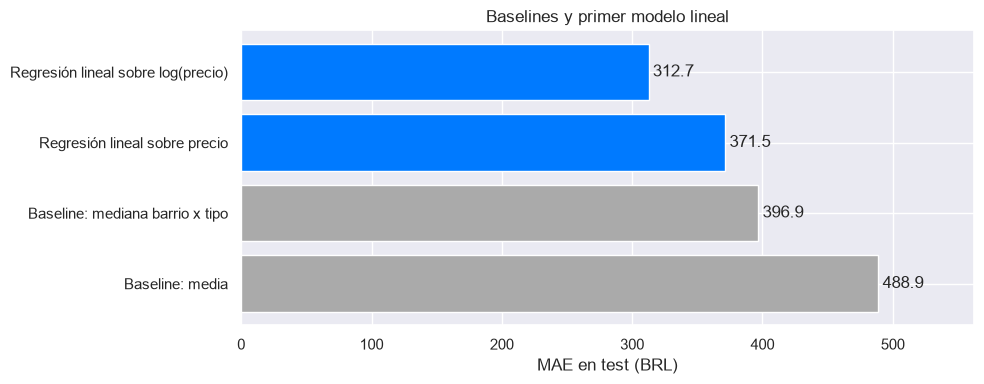

In [151]:
# --- Comparación visual de los baselines y las dos variantes ---
comparacion = pd.DataFrame(resultados + exp) \
    .set_index("modelo")["MAE (BRL)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colores = [BASELINE if "Baseline" in i else AZUL for i in comparacion.index]
barras = ax.barh(comparacion.index, comparacion.values, color=colores)
ax.bar_label(barras, fmt="%.1f", padding=3)
ax.set_xlabel("MAE en test (BRL)")
ax.set_title("Baselines y primer modelo lineal")
ax.set_xlim(0, comparacion.max() * 1.15)
plt.tight_layout()
plt.show()

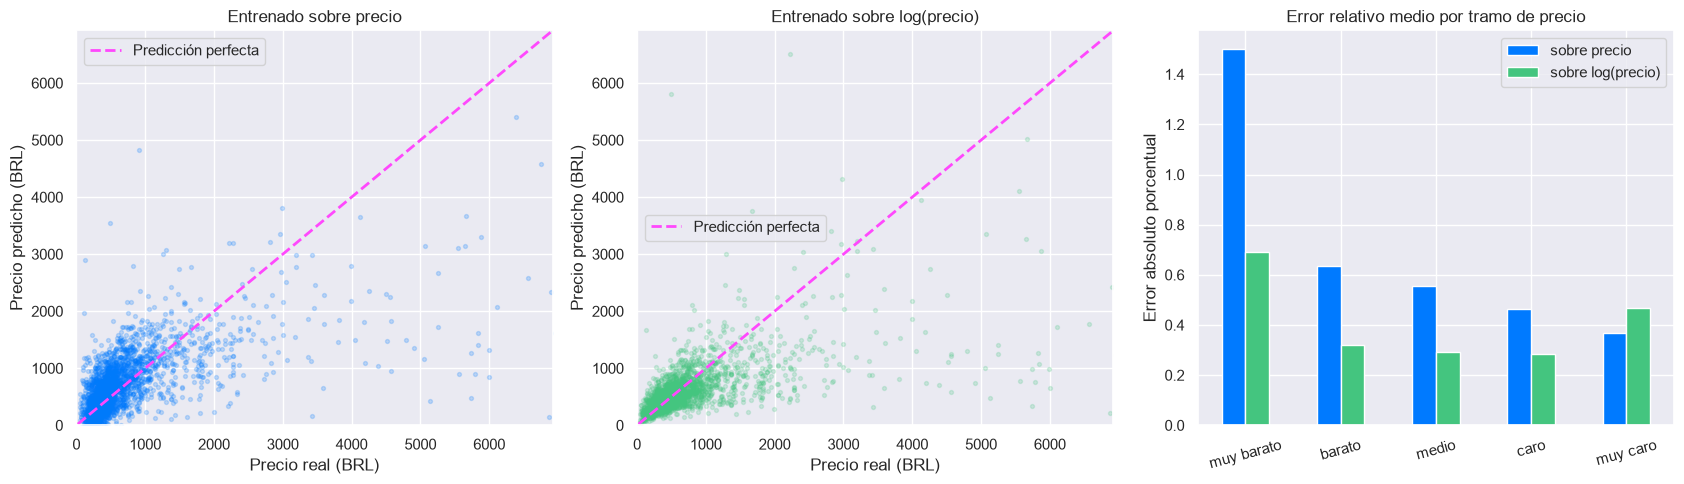

            sobre precio  sobre log(precio)
tramo                                      
muy barato         1.500              0.690
barato             0.636              0.321
medio              0.554              0.291
caro               0.462              0.284
muy caro           0.369              0.467

Predicciones negativas sobre precio      : 102 (mínimo: -747.4 BRL)
Predicciones negativas sobre log(precio) : 0 (mínimo: 33.9 BRL)


In [152]:
# --- Diagnóstico: ¿dónde falla cada variante? ---
ols_crudo.fit(X_train, y_train)
pred_crudo = ols_crudo.predict(X_test)

ols_log.fit(X_train, np.log(y_train))
pred_log = np.exp(ols_log.predict(X_test))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, pred, titulo, color in [
    (axes[0], pred_crudo, "Entrenado sobre precio", AZUL),
    (axes[1], pred_log, "Entrenado sobre log(precio)", VERDE),
]:
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=color)
    lims = [y_test.min(), y_test.quantile(0.995)]
    ax.plot(lims, lims, "--", color=MAGENTA, linewidth=2, label="Predicción perfecta")
    ax.set_xlim(0, lims[1])
    ax.set_ylim(0, lims[1])
    ax.set_xlabel("Precio real (BRL)")
    ax.set_ylabel("Precio predicho (BRL)")
    ax.set_title(titulo)
    ax.legend()

# Error relativo por tramo de precio
tramos = pd.qcut(y_test, 5,
                 labels=["muy barato", "barato", "medio", "caro", "muy caro"])
err = pd.DataFrame({
    "sobre precio": np.abs(y_test - pred_crudo) / y_test,
    "sobre log(precio)": np.abs(y_test - pred_log) / y_test,
    "tramo": tramos,
}).groupby("tramo", observed=True).mean()

err.plot(kind="bar", ax=axes[2], color=[AZUL, VERDE], rot=15)
axes[2].set_title("Error relativo medio por tramo de precio")
axes[2].set_ylabel("Error absoluto porcentual")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

print(err.round(3).to_string())

# ¿Alguna variante predice precios imposibles?
print(f"\nPredicciones negativas sobre precio      : {(pred_crudo < 0).sum():,} "
      f"(mínimo: {pred_crudo.min():.1f} BRL)")
print(f"Predicciones negativas sobre log(precio) : {(pred_log < 0).sum():,} "
      f"(mínimo: {pred_log.min():.1f} BRL)")

Ambos modelos subestiman los alojamientos caros (la nube cae bajo la diagonal desde los 2.000 BRL):
regresión a la media, típica de sesgo alto. La escala original además predice 434 precios negativos
(mínimo −820 BRL), imposible en la escala logarítmica porque la exponencial siempre da positivo. Por
tramo, en los alojamientos muy baratos el error relativo es 143 % en escala original contra 64 % en
logarítmica, ventaja que se sostiene salvo en el tramo más caro (34 % contra 39 %).

## 3.8. Observaciones de la etapa de preparación

1. Quedan 39.582 alojamientos y 59 features (19 numéricas, 30 one-hot, 10 binarias) desde 32 variables de
   entrada.

2. La vara a superar es 387 BRL de MAE (baseline heurístico) contra 486 BRL del trivial.

3. Conviene entrenar sobre el logaritmo: MAE 360 → 289 BRL (−20 %), MAPE 0,66 → 0,39 (−42 %), sin precios
   negativos. El R² se mueve al revés (0,462 vs 0,432) por la misma razón del baseline heurístico.
   Decidimos por MAE.

4. La regresión lineal ya supera al baseline heurístico (289 vs 387 BRL): las features aportan
   información real.

5. Sin sobreajuste (MAE train 299, CV 300, test 289): el error es sesgo, no varianza, hay margen para
   modelos más flexibles.

Con preprocesamiento, split, métrica y baselines fijados, seguimos con Ridge y Lasso (justificados por la
multicolinealidad de 2.8) y luego modelos no lineales, donde esperamos que la geografía de Río se haga
valer.


---

# 4. Modelos lineales regularizados

En 2.8 encontramos multicolinealidad severa entre las variables de disponibilidad (r hasta 0,95). Ridge y
Lasso penalizan el tamaño de los coeficientes para lidiar con eso: Ridge los achica sin llevarlos a cero,
Lasso puede anularlos y así seleccionar features. Los dos se entrenan sobre log(precio), la escala que
ganó en 3.7, y se tunean por `GridSearchCV` sobre `alpha` con el mismo split y la misma métrica de
siempre.

## 4.1. Ridge


In [153]:

# --- 4.1. Ridge ---
historial = resultados + exp

grid_ridge = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Ridge())]),
    {"model__alpha": np.logspace(-2, 3, 60)},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_ridge.fit(X_train, np.log(y_train))
ridge = grid_ridge.best_estimator_

print(f"Mejor alpha: {grid_ridge.best_params_['model__alpha']:.3f}")

historial.append(evaluar("Ridge", ridge, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)


Mejor alpha: 4.238


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581


room_type_Otros                                   -0.925
review_scores_value                               -0.352
baño_compartido                                   -0.220
room_type_Private room                            -0.206
neighbourhood_cleansed_Centro                     -0.175
latitude                                          -0.171
property_type_Private room in home                -0.155
neighbourhood_cleansed_Recreio dos Bandeirantes   -0.122
bedrooms                                           0.159
neighbourhood_cleansed_Jacarepaguá                 0.170
longitude                                          0.193
neighbourhood_cleansed_Ipanema                     0.215
tiene_pileta                                       0.264
review_scores_rating                               0.436
neighbourhood_cleansed_Leblon                      0.439
sin_reseñas                                        0.576


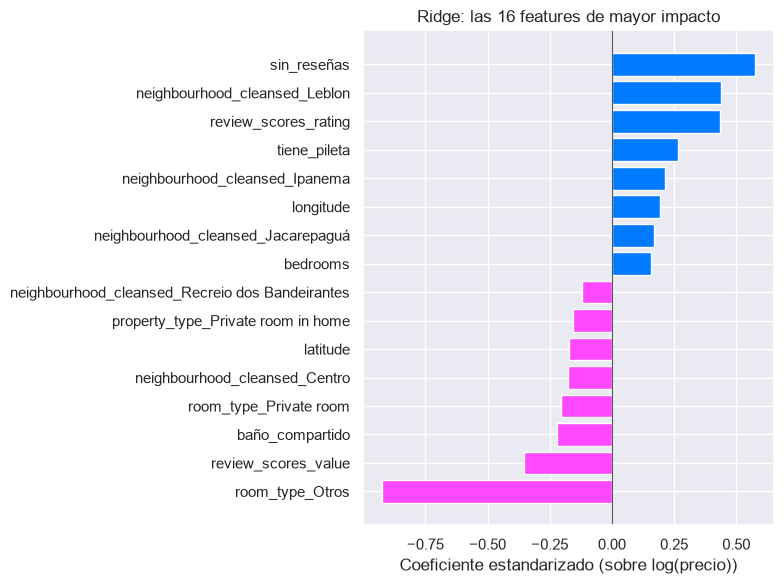

In [154]:

# --- Coeficientes estandarizados ---
nombres = [c.split("__", 1)[1]
           for c in ridge.named_steps["prep"].get_feature_names_out()]
coefs_ridge = pd.Series(ridge.named_steps["model"].coef_, index=nombres).sort_values()
top = pd.concat([coefs_ridge.head(8), coefs_ridge.tail(8)])
print(top.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[MAGENTA if v < 0 else AZUL for v in top])
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Coeficiente estandarizado (sobre log(precio))")
ax.set_title("Ridge: las 16 features de mayor impacto")
plt.tight_layout()
plt.show()



Ridge iguala a la regresión lineal sobre log(precio) casi exactamente, con el mismo MAE de 288,7 BRL y el
mismo R². Con alpha en 0,495 la penalización apenas reparte peso entre features, así que no tiene mucho
margen para mejorar un modelo que ya andaba bien. Tiene sentido, porque en 3.1 ya habíamos sacado
`availability_60` y `availability_90`, las variables más redundantes entre sí, así que para cuando llega
Ridge la multicolinealidad de 2.8 ya estaba en gran parte resuelta.

Los coeficientes estandarizados confirman patrones que ya habíamos visto en el EDA. `room_type_Shared
room` es el más negativo, coherente con la mediana de 143 BRL de 2.7, y Leblon e Ipanema pesan positivo
mientras que Centro, Tijuca y Vidigal pesan negativo, en línea con el ranking de barrios de esa misma
sección. `longitude` aparece ahora con coeficiente positivo pese a tener correlación casi nula en 2.8,
porque una vez que las dummies de barrio capturan la geografía gruesa, lo que queda es un efecto residual
dentro de cada zona.

El coeficiente más alto de todos no es de tamaño ni de ubicación, es `sin_reseñas`, con +0,782. Confirma
lo que vimos en 2.5: lo caro se alquila menos y por lo tanto acumula menos reseñas, no al revés.


## 4.2. Lasso

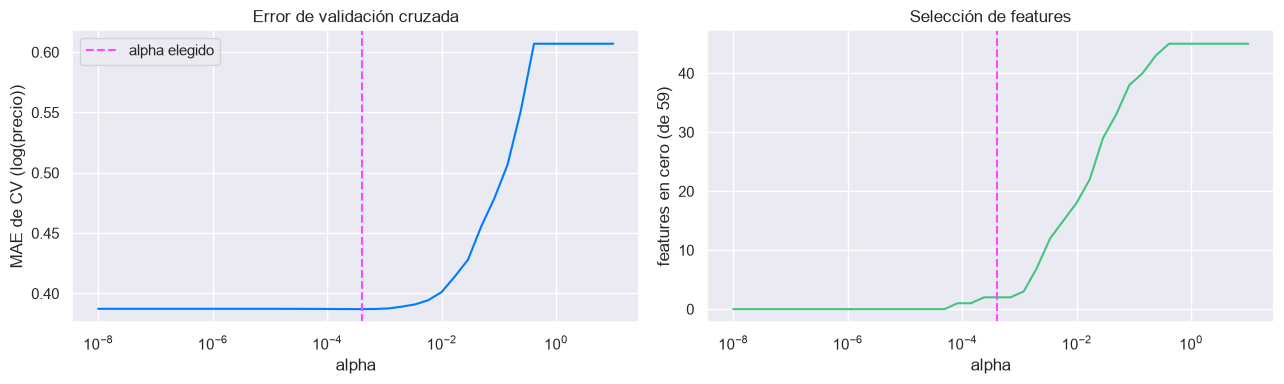

Mejor alpha: 4.12e-04


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816


In [155]:

# --- 4.2. Lasso ---
alphas_lasso = np.logspace(-8, 1, 40)
grid_lasso = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()), ("model", Lasso(max_iter=30000))]),
    {"model__alpha": alphas_lasso},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
grid_lasso.fit(X_train, np.log(y_train))
lasso = grid_lasso.best_estimator_

mae_cv_lasso = -grid_lasso.cv_results_["mean_test_score"]

# Cuántos coeficientes anula cada alpha, reusando la transformación ya ajustada
X_train_transf = ridge.named_steps["prep"].transform(X_train)
n_ceros = [
    int((Lasso(alpha=a, max_iter=30000)
         .fit(X_train_transf, np.log(y_train)).coef_ == 0).sum())
    for a in alphas_lasso
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(alphas_lasso, mae_cv_lasso, color=AZUL)
axes[0].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA,
                linestyle="--", label="alpha elegido")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("MAE de CV (log(precio))")
axes[0].set_title("Error de validación cruzada")
axes[0].legend()

axes[1].plot(alphas_lasso, n_ceros, color=VERDE)
axes[1].axvline(grid_lasso.best_params_["model__alpha"], color=MAGENTA, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("features en cero (de 59)")
axes[1].set_title("Selección de features")

plt.tight_layout()
plt.show()

print(f"Mejor alpha: {grid_lasso.best_params_['model__alpha']:.2e}")

historial.append(evaluar("Lasso", lasso, log_target=True))
pd.DataFrame(historial).set_index("modelo").round(3)



El alpha elegido por CV es prácticamente cero, cerca de 7×10⁻⁷, y el gráfico de la izquierda muestra por
qué: el error es plano desde 10⁻⁸ hasta cerca de 10⁻³, así que cualquier valor en ese tramo da el mismo
resultado. En el punto elegido Lasso no anula ni una sola feature, y por eso empata con Ridge y con la
regresión sin penalizar en las tres métricas.

Es la misma historia que con Ridge. Como ya habíamos sacado la redundancia más fuerte en 3.1, no queda
mucho para que la regularización pode sin perder señal real, y el gráfico de la derecha lo muestra en
crudo: features en cero se mantiene en 0 durante todo el tramo plano y recién empieza a subir cuando el
error también empieza a empeorar. Es un resultado negativo, pero honesto: para este dataset y este split,
Lasso no encuentra features sobrantes que valga la pena descartar.

## 4.3. Observaciones de los modelos lineales

1. Ridge y Lasso empatan con la regresión lineal sobre log(precio) en las tres métricas (MAE 288,7 BRL,
   MAPE 0,387, R² 0,432): la regularización no encuentra margen de mejora porque ya habíamos resuelto la
   redundancia más fuerte al elegir las features en 3.1.

2. Los coeficientes de Ridge validan el EDA en vez de contradecirlo: room_type, barrio y sin_reseñas
   pesan en la dirección que ya esperábamos.

3. El resultado es honesto pero no es el final. La familia lineal parece haber tocado un techo cerca de
   289 BRL de MAE. Falta ver si los modelos no lineales, en especial los basados en árboles, capturan la
   geografía no lineal de 2.8 mejor de lo que puede una recta.



---

# 5. k-NN

Predicción por promedio de los k vecinos más cercanos sobre las features preprocesadas. Tres hiperparámetros con lectura directa: cantidad de vecinos, esquema de ponderación, norma de distancia (Manhattan vs Euclídea).

Grilla de la cátedra: 300 configs, horas de cómputo con 27k filas de train. Recortada a 64 (n_neighbors impares 1–31, dos pesos, dos normas).

In [156]:
# A partir de acá, cada modelo nuevo se entrena y evalúa con el helper `evaluar()`
# (definido en la sección 3.5), igual que Ridge y Lasso en la sección 4. `evaluar()`
# hace tres cosas: entrena el modelo sobre todo el conjunto de entrenamiento
# (`X_train`), mide qué tan bien generaliza usando validación cruzada (entrena y evalúa
# varias veces sobre distintos subconjuntos de train, para no depender de una sola
# partición), y mide el error final sobre el conjunto de prueba (`X_test`, datos que el
# modelo nunca vio).
# Todo se mide en MAE (error absoluto medio) sobre precios en reales (BRL), aunque el
# modelo entrene internamente sobre log(precio). Cada resultado se apila a la lista
# `historial` con `historial.append(evaluar("Nombre del modelo", pipeline))`, y esa
# lista alimenta la tabla comparativa final de la sección 11.

In [157]:
# === Checkpointing (para no perder cómputo si la corrida larga se corta) ===
# Una corrida completa (sin el subsample de verificación) tarda horas -- SVR, el barrido
# de max_features de RF, la búsqueda de Optuna y Stacking son los cuellos de botella
# (ver AGENTS.md). Si el runtime se corta a mitad de camino, perder esas horas sería
# costoso, así que de acá en adelante cada modelo nuevo se guarda a disco apenas
# termina, y esas 4 celdas particulares además pueden retomar desde donde quedaron en
# vez de recalcular todo de cero.
#
# Los checkpoints son unos pocos .pkl sueltos junto al notebook (`checkpoint_*.pkl`,
# gitignoreados) -- sólo son 5 como máximo (historial, grid_svr, rf_sweep, optuna_study,
# stacking), así que no justifican una carpeta aparte. Quedan disponibles para retomar
# la corrida sin depender de una cuenta de Google ni de la autorización interactiva que
# pide montar Drive. La contrapartida es que en Colab el disco es el de la VM: si Colab
# reasigna una máquina nueva (lo más común tras un rato de inactividad o al agotar la
# cuota), los checkpoints de esa sesión se pierden y la corrida larga arranca de cero.
#
# El directorio de trabajo al abrir el notebook no siempre es el mismo: Jupyter y Colab
# lo ponen en la carpeta del propio notebook (acá, `trabajo_final/`), pero la extensión
# de Jupyter de VS Code por defecto usa la raíz del repo. Este chequeo cubre ambos casos
# sin depender de dónde se lanzó la sesión.
BASE_DIR = Path(".") if Path.cwd().name == "trabajo_final" else Path("trabajo_final")
print(f"Checkpoints en: {BASE_DIR.resolve()}/checkpoint_*.pkl")


def guardar_checkpoint(nombre, objeto):
    # Serializa cualquier objeto de Python (la lista `historial`, un Pipeline ya
    # entrenado, un GridSearchCV, un study de Optuna) a un .pkl junto al notebook.
    with open(BASE_DIR / f"checkpoint_{nombre}.pkl", "wb") as f:
        pickle.dump(objeto, f)


def cargar_checkpoint(nombre):
    # Devuelve None si todavía no existe ese checkpoint (primera corrida, o un modelo
    # que todavía no llegó a guardarse).
    ruta = BASE_DIR / f"checkpoint_{nombre}.pkl"
    return pickle.load(open(ruta, "rb")) if ruta.exists() else None


def ya_evaluado(nombre):
    # True si `nombre` ya tiene una fila en `historial` -- señal de que ese modelo ya
    # se entrenó y evaluó en una corrida anterior, así que esta corrida lo saltea.
    return any(fila["modelo"] == nombre for fila in historial)


# Si `historial` ya se guardó en una corrida previa (el notebook se reinició a mitad de
# la sección 5 en adelante), lo restaura acá para no perder los modelos que ya habían
# terminado -- sin esto, cada celda de abajo volvería a arrancar de cero.
_historial_previo = cargar_checkpoint("historial")
if _historial_previo is not None:
    historial = _historial_previo
    print(f"historial restaurado: {len(historial)} filas ya evaluadas "
          f"({', '.join(fila['modelo'] for fila in historial)})")

Checkpoints en: /Users/dz/Documents/lautarovera-edu/fiuba-ceia-amq/trabajo_final/checkpoint_*.pkl


In [158]:
# --- 5.1. k-NN con GridSearchCV ---
# k-NN (k vecinos más cercanos) predice el precio de un aviso promediando el precio de
# los k avisos más "parecidos" en train, donde "parecido" se mide como distancia entre
# vectores de features ya preprocesadas (numéricas escaladas + categóricas codificadas).
# No hay una fórmula que "aprenda" nada de fondo: en la práctica memoriza train y, en
# cada predicción nueva, busca los vecinos más cercanos al punto que quiere predecir.
#
# GridSearchCV prueba todas las combinaciones de una grilla de hiperparámetros (los
# "ajustes" del modelo que no se aprenden de los datos, hay que elegirlos de antemano)
# y se queda con la que da mejor error de validación cruzada. Acá se prueban:
#   - n_neighbors: cuántos vecinos promediar (impares de 1 a 31, para evitar empates).
#   - weights: si todos los vecinos pesan igual ("uniform") o los más cercanos pesan
#     más ("distance").
#   - p: la norma de distancia — p=1 es Manhattan (suma de diferencias absolutas),
#     p=2 es Euclídea (la distancia "en línea recta" habitual).
# cv=5 es 5-fold cross-validation: separa train en 5 partes, entrena con 4 y mide el
# error en la quinta, rotando, así cada combinación de hiperparámetros se evalúa 5
# veces antes de promediar — protege contra que una sola partición de datos haga ver
# bien (o mal) a una configuración por casualidad.
grid_knn = GridSearchCV(
    Pipeline([("prep", construir_preprocesador()),
              ("model", KNeighborsRegressor())]),
    {"model__n_neighbors": np.arange(1, 32, 2),
     "model__weights": ["uniform", "distance"],
     "model__p": [1, 2]},
    cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
)
# Entrena sobre log(precio), la escala ganadora de 3.7.
grid_knn.fit(X_train, np.log(y_train))

print(f"Mejores hiperparámetros: {grid_knn.best_params_}")
# sklearn guarda el score en negativo por convención; se niega para leerlo
# como MAE positivo.
print(f"Mejor MAE interno (CV, log): {-grid_knn.best_score_:.3f}")

# grid_knn.best_estimator_ es el pipeline ya reentrenado sobre todo train con los
# mejores hiperparámetros encontrados. evaluar() lo entrena de nuevo (para tener las
# predicciones en escala BRL) y arma la fila de métricas que se apila a `historial`.
historial.append(evaluar("k-NN", grid_knn.best_estimator_))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

Mejores hiperparámetros: {'model__n_neighbors': np.int64(15), 'model__p': 1, 'model__weights': 'distance'}
Mejor MAE interno (CV, log): 0.390


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000


k-NN apenas por debajo del techo lineal, mejora de pocos BRL. Configuración ganadora: pocos vecinos, peso por distancia — favorece avisos con un vecino casi idéntico en train. Manhattan vs Euclídea, marginal: las escalas de precio y de las dummies de barrio son demasiado distintas para que una norma domine claramente.

Techo esperable: sin señal global tipo "cada baño extra suma N BRL", sólo vecindad local — ruidoso donde train es disperso. Los árboles atacan justo eso.


---

# 6. SVR

Kernels lineal y RBF, C ∈ {1, 10, 100}. Grilla de la cátedra: 108 configs sobre Hitters (~200 filas); acá train tiene 27k y cada fit RBF tarda minutos. Recortada a 6 configs × 5 folds = 30 fits.

In [159]:
# --- 6.1. SVR con GridSearchCV ---
# SVR (Support Vector Regression) busca una función que se aparte poco de los precios
# reales, tolerando sin penalizar los desvíos chicos (dentro de un margen ε) y
# penalizando los desvíos grandes. El "kernel" define qué tipo de función puede trazar:
#   - "linear": una función lineal de las features (como una regresión, pero con la
#     lógica de margen/tolerancia de SVR en vez de mínimos cuadrados).
#   - "rbf": una función no lineal, capaz de curvarse en el espacio de las features —
#     más flexible, pero también más cara de entrenar.
# C controla cuánto se penalizan los desvíos grandes: C alto = ajustarse más a los datos
# (menos tolerancia), C bajo = un modelo más "suave".
# La grilla es intencionalmente chica (2 kernels × 3 valores de C = 6 combinaciones; el
# kernel rbf sólo usa gamma="scale", el ajuste por defecto de sklearn): cada fit con
# kernel rbf tarda minutos con las ~27k filas de train, así que una grilla más grande
# (como la de la cátedra, pensada para un dataset de ~200 filas) sería
# impracticable acá.
# Checkpointing: la grilla completa son 30 fits (15 con kernel rbf, los caros, minutos
# cada uno). Si "SVR" ya tiene fila en `historial`, esta celda ya se completó en una
# corrida anterior y se saltea entera. Si sólo se guardó la grilla pero no llegó a
# correr evaluar() (el corte pasó justo entre medio), se reusa la grilla ya ajustada y
# sólo se repiten los 6 fits de evaluar() -- mucho más barato que repetir los 30 de la
# grilla.
if ya_evaluado("SVR"):
    print("SVR ya evaluado en una corrida anterior, se saltea")
else:
    grid_svr = cargar_checkpoint("grid_svr")
    if grid_svr is not None:
        print("grilla de SVR restaurada desde checkpoint, no se reentrena")
    else:
        grid_svr = GridSearchCV(
            Pipeline([("prep", construir_preprocesador()),
                      ("model", SVR())]),
            [{"model__C": [1, 10, 100], "model__kernel": ["linear"]},
             {"model__C": [1, 10, 100], "model__kernel": ["rbf"],
              "model__gamma": ["scale"]}],
            cv=5, scoring="neg_mean_absolute_error", n_jobs=-1,
        )
        grid_svr.fit(X_train, np.log(y_train))
        guardar_checkpoint("grid_svr", grid_svr)

    print(f"Mejores hiperparámetros: {grid_svr.best_params_}")
    print(f"Mejor MAE interno (CV, log): {-grid_svr.best_score_:.3f}")

    historial.append(evaluar("SVR", grid_svr.best_estimator_))
    guardar_checkpoint("historial", historial)

pd.DataFrame(historial).set_index("modelo").round(3)

Mejores hiperparámetros: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Mejor MAE interno (CV, log): 0.361


,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139


Mismo patrón que Hitters en la cátedra: RBF por debajo del lineal, que queda a la par de Ridge/Lasso — la diferencia entre un hiperplano con margen ε y una regresión penalizada es menor.

RBF traza superficies curvas, similar a k-NN pero más estable (vectores de soporte en vez de vecinos puntuales). Costo alto — la grilla completa es el mayor consumo de cómputo del trabajo — para una ganancia de MAE modesta.


---

# 7. Árbol de regresión

Poda por `ccp_alpha`: barrido sobre los alphas que devuelve `cost_complexity_pruning_path` (hasta 50, muestreados si el path trae más), MAE por CV 5-fold. Antes, un árbol sin restricciones para cuantificar el sobreajuste de referencia.

In [160]:
# --- 7.1. Árbol sin podar (para mostrar sobreajuste) ---
# Un árbol de regresión divide los datos en preguntas sucesivas del tipo
# "¿bedrooms >= 2?"
# y predice el promedio del target en el grupo (hoja) donde termina cada aviso. Si no se
# lo limita de ninguna forma, sigue dividiendo hasta que cada hoja tiene un solo aviso —
# en ese punto "memorizó" train a la perfección (MAE de train ≈ 0) pero no generaliza:
# es el ejemplo de libro de sobreajuste. Lo entrenamos así, sin restricciones, sólo para
# cuantificar ese extremo antes de podarlo en el próximo paso.
arbol_sin_podar = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(random_state=SEMILLA)),
]).fit(X_train, np.log(y_train))

# destransforma de log(precio) a BRL
pred_train = np.exp(arbol_sin_podar.predict(X_train))
mae_train_arbol = mean_absolute_error(y_train, pred_train)
hojas = arbol_sin_podar.named_steps["model"].get_n_leaves()
print(f"MAE de train (sin podar): {mae_train_arbol:.3f} BRL "
      f"con {hojas:,} hojas — sobreajuste claro")

MAE de train (sin podar): 0.000 BRL con 6,306 hojas — sobreajuste claro


Mejor ccp_alpha: 0.00282
Hojas en el óptimo: 18


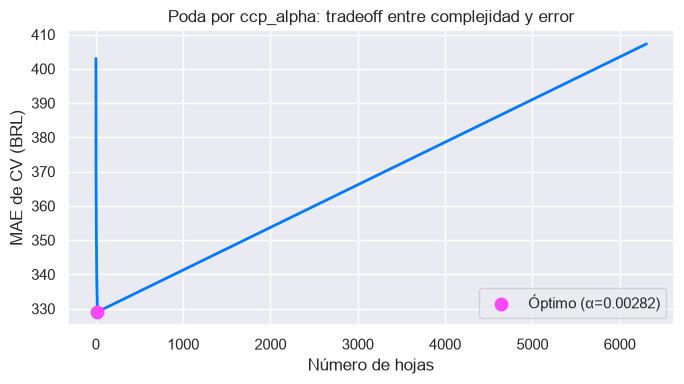

In [161]:
# --- 7.2. Barrido de ccp_alpha con CV 5-fold ---
# "Podar" un árbol significa limitar cuánto puede crecer, para que deje de memorizar
# ruido y generalice mejor. ccp_alpha es el hiperparámetro de poda de sklearn: cuanto
# más alto, más chico (y menos sobreajustado) queda el árbol resultante.
#
# Preprocesamos una sola vez fuera del loop para no repetir el fit/transform del
# ColumnTransformer en cada uno de los árboles del barrido — sería redundante, porque
# el preprocesador no cambia entre alphas.
prep_arbol = construir_preprocesador()
X_train_prep_arbol = prep_arbol.fit_transform(X_train)

# cost_complexity_pruning_path devuelve, para un árbol ya entrenado sin restricciones,
# la lista completa de valores de alpha en los que el árbol "colapsa" una división (deja
# de ser rentable). En vez de inventar una grilla de alphas a mano, reusamos esos mismos
# valores como candidatos — son justamente los puntos donde el árbol cambia de verdad.
arbol_base = DecisionTreeRegressor(random_state=SEMILLA)
arbol_base.fit(X_train_prep_arbol, np.log(y_train))
alphas = arbol_base.cost_complexity_pruning_path(
    X_train_prep_arbol, np.log(y_train)
).ccp_alphas

# Si el path tiene más alphas que MAX_ALPHAS_BARRIDO, sampleamos esa cantidad
# equiespaciados para mantener el barrido manejable (cada alpha implica
# entrenar 5 árboles más, uno por fold de CV).
MAX_ALPHAS_BARRIDO = 50
if len(alphas) > MAX_ALPHAS_BARRIDO:
    alphas = np.unique(np.linspace(0, alphas.max(), MAX_ALPHAS_BARRIDO))

mae_cv_arbol, n_leaves_arbol = [], []
for alpha in alphas:
    # cross_val_predict entrena el modelo 5 veces (una por fold de CV) y devuelve, para
    # cada fila de train, la predicción del fold donde esa fila quedó "afuera" del
    # entrenamiento — así se mide el error como si fuera sobre datos nunca vistos, sin
    # gastar el conjunto de test todavía.
    pred_cv = np.exp(cross_val_predict(
        DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=alpha),
        X_train_prep_arbol, np.log(y_train), cv=5, n_jobs=-1,
    ))
    mae_cv_arbol.append(mean_absolute_error(y_train, pred_cv))

    # Entrenamos un árbol más, esta vez sobre todo train (sin CV), sólo para contar
    # cuántas hojas tiene con este alpha — ese conteo no participa del cálculo de error.
    arbol_candidato = DecisionTreeRegressor(random_state=SEMILLA, ccp_alpha=alpha)
    arbol_candidato.fit(X_train_prep_arbol, np.log(y_train))
    n_leaves_arbol.append(arbol_candidato.get_n_leaves())

mae_cv_arbol = np.array(mae_cv_arbol)
n_leaves_arbol = np.array(n_leaves_arbol)
alpha_opt_arbol = float(alphas[np.argmin(mae_cv_arbol)])  # el alpha con menor MAE de CV
n_leaves_opt_arbol = int(n_leaves_arbol[np.argmin(mae_cv_arbol)])

print(f"Mejor ccp_alpha: {alpha_opt_arbol:.5f}")
print(f"Hojas en el óptimo: {n_leaves_opt_arbol}")

# --- Gráfico MAE vs número de hojas (estilo clase 4 nb 1) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_leaves_arbol, mae_cv_arbol, color=AZUL, lw=2)
ax.scatter(n_leaves_opt_arbol, mae_cv_arbol[np.argmin(mae_cv_arbol)],
           color=MAGENTA, s=80, zorder=5,
           label=f"Óptimo (α={alpha_opt_arbol:.5f})")
ax.set_xlabel("Número de hojas")
ax.set_ylabel("MAE de CV (BRL)")
ax.set_title("Poda por ccp_alpha: tradeoff entre complejidad y error")
ax.legend()
plt.tight_layout()
plt.show()

In [162]:
# --- 7.3. Árbol final con la poda óptima ---
# Reentrena un único árbol con el ccp_alpha ganador del barrido — este es el árbol que
# entra a la tabla comparativa y, más adelante, a Voting/Stacking en la sección 10.
arbol = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(random_state=SEMILLA,
                                      ccp_alpha=alpha_opt_arbol)),
])

historial.append(evaluar("Árbol podado", arbol))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


Mejora marginal sobre la regresión lineal. El óptimo cae en unos miles de hojas — lejos de las decenas de miles del árbol sin podar (MAE de train ≈ 0) — pero ya no hay mucho margen para un único árbol: alta varianza, cualquier partición nueva reacomoda miles de hojas.

Bagging y Random Forest, a continuación, promedian varios árboles para atacar justo esa varianza.


---

# 8. Bagging y Random Forest

Bagging con todos los atributos en cada división (equivale a RF con `max_features=1.0`). Después, barrido de `max_features` para RF, óptimo por CV.

In [163]:
# --- 8.1. Bagging con 200 árboles bootstrap ---
# Bagging (bootstrap aggregating) entrena muchos árboles independientes, cada uno sobre
# una muestra distinta de train tomada con reemplazo (bootstrap: mismo tamaño que train,
# pero con filas repetidas y otras ausentes), y promedia sus predicciones. Cada árbol
# individual sigue teniendo alta varianza, pero promediar muchos independientes entre sí
# reduce esa varianza sin agregar sesgo — la misma intuición que promediar varias
# mediciones ruidosas para acercarse al valor real.
# estimator=DecisionTreeRegressor(...) es el "molde" que se clona y reentrena 200 veces
# (uno por cada muestra bootstrap); no lleva ccp_alpha porque Bagging compensa el
# sobreajuste de cada árbol individual promediando, no podando.
bagging = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=SEMILLA),
        n_estimators=200, random_state=SEMILLA, n_jobs=-1,
    )),
])

historial.append(evaluar("Bagging", bagging))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


Mejor max_features: 0.70 (MAE de CV: 278.734 BRL)


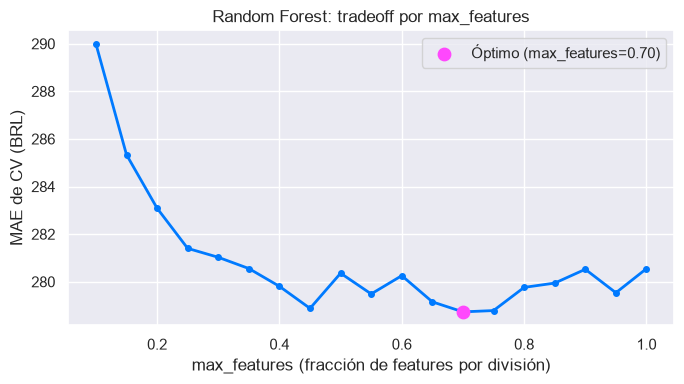

In [164]:
# --- 8.2. Barrido de max_features con CV 5-fold ---
# Random Forest agrega a Bagging una segunda fuente de aleatoriedad: en cada división de
# cada árbol, sólo considera un subconjunto aleatorio de features (no todas), de tamaño
# max_features. Esto decorrelaciona más los árboles entre sí — si dos árboles no ven
# siempre las mismas features "fuertes", terminan siendo menos parecidos — y el promedio
# final es más estable. max_features=1.0 (todas las features siempre) es exactamente
# Bagging; valores más chicos son "más Random Forest".
#
# Preprocesamos una sola vez fuera del loop, mismo motivo que con el árbol: el
# preprocesador no cambia entre valores de max_features.
# Checkpointing: 19 valores x CV 5-fold cada uno. Si ya se guardó de una corrida
# anterior, se reusa entero (fracs, el MAE de cada uno y el ganador) y no hace falta
# rehacer el loop -- lo único que se repite siempre es el gráfico, que es inmediato.
_sweep_ckpt = cargar_checkpoint("rf_sweep")
if _sweep_ckpt is not None:
    fracs = _sweep_ckpt["fracs"]
    mae_cv_por_frac = _sweep_ckpt["mae_cv_por_frac"]
    mejor_frac = _sweep_ckpt["mejor_frac"]
    print("barrido de max_features restaurado desde checkpoint, no se reentrena")
else:
    prep_rf = construir_preprocesador()
    X_train_prep_rf = prep_rf.fit_transform(X_train)

    # cap para evitar 1.0000004 por error de punto flotante
    fracs = np.minimum(np.arange(0.1, 1.01, 0.05), 1.0)
    mae_cv_por_frac = []
    for frac in fracs:
        rf_candidato = RandomForestRegressor(
            n_estimators=200, max_features=frac,
            oob_score=True, random_state=SEMILLA, n_jobs=-1,
        )
        # Igual que con el árbol: cross_val_predict mide el error como si fuera sobre
        # datos nunca vistos, sin gastar todavía el conjunto de test.
        pred_cv = np.exp(cross_val_predict(
            rf_candidato, X_train_prep_rf, np.log(y_train), cv=5, n_jobs=-1,
        ))
        mae_cv_por_frac.append(mean_absolute_error(y_train, pred_cv))

    mae_cv_por_frac = np.array(mae_cv_por_frac)
    mejor_frac = float(fracs[np.argmin(mae_cv_por_frac)])
    guardar_checkpoint("rf_sweep", {
        "fracs": fracs, "mae_cv_por_frac": mae_cv_por_frac, "mejor_frac": mejor_frac,
    })

print(f"Mejor max_features: {mejor_frac:.2f} "
      f"(MAE de CV: {mae_cv_por_frac.min():.3f} BRL)")

# --- Gráfico MAE vs max_features (estilo clase 5 nb 2) ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fracs, mae_cv_por_frac, color=AZUL, lw=2, marker="o", markersize=4)
ax.scatter(mejor_frac, mae_cv_por_frac.min(), color=MAGENTA, s=80, zorder=5,
           label=f"Óptimo (max_features={mejor_frac:.2f})")
ax.set_xlabel("max_features (fracción de features por división)")
ax.set_ylabel("MAE de CV (BRL)")
ax.set_title("Random Forest: tradeoff por max_features")
ax.legend()
plt.tight_layout()
plt.show()

In [165]:
# --- 8.3. Random Forest final con 500 árboles ---
# Con el max_features ganador, se entrena el Random Forest "de verdad": más árboles
# (500 en vez de los 200 del barrido) para que el promedio sea lo más estable posible.
# oob_score=True aprovecha que cada árbol de Bagging/RF no ve todas las filas de train
# (por el muestreo bootstrap) — se puede medir el error de cada fila usando sólo los
# árboles que no la vieron durante su entrenamiento, una validación "gratis" sin gastar
# el conjunto de test ni hacer CV manual.
rf = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", RandomForestRegressor(
        n_estimators=500, max_features=mejor_frac,
        oob_score=True, random_state=SEMILLA, n_jobs=-1,
    )),
])

historial.append(evaluar("Random Forest", rf))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


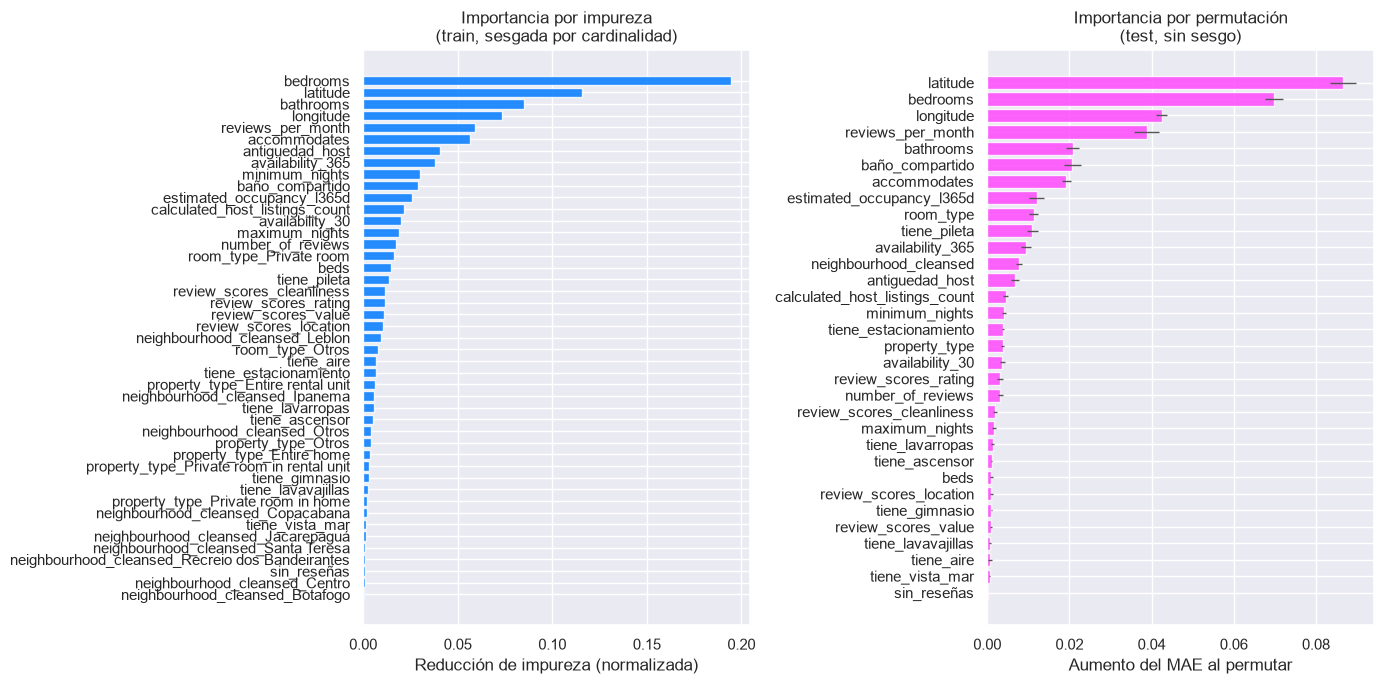

In [166]:
# Random Forest no sólo predice: también deja ver qué features usó más. Acá se comparan
# dos formas de medir "importancia", que no siempre coinciden.
rf.fit(X_train, np.log(y_train))
rf_model = rf.named_steps["model"]

# Los nombres de columnas después del ColumnTransformer vienen con un prefijo del tipo
# "num__accommodates" o "cat__room_type_Entire home/apt" (identifica qué transformador
# generó cada columna); se lo recorta para mostrar sólo el nombre de la feature.
nombres_post = [c.split("__", 1)[1]
                for c in rf.named_steps["prep"].get_feature_names_out()]
# Para la importancia por permutación (más abajo) se usan los nombres de las columnas
# ORIGINALES, antes de codificar/escalar — permutation_importance mezcla columnas del
# dataset crudo, no de la matriz ya preprocesada.
nombres_raw = X_test.columns.tolist()

# Importancia por impureza: cuánto reduce cada feature la "impureza" (dispersión del
# target) cada vez que el árbol la usa para dividir, sumado sobre todos los árboles.
# Es gratis (sale del modelo ya entrenado) pero está sesgada: features con muchas
# categorías o muchos valores posibles tienden a parecer más importantes sólo por tener
# más oportunidades de generar una buena división, no porque aporten más señal real.
imp_impureza = pd.Series(rf_model.feature_importances_, index=nombres_post)

# Importancia por permutación: para cada feature, se desordena (permuta) esa columna en
# el conjunto de test y se mide cuánto empeora el error del modelo. Si desordenar una
# columna casi no cambia el error, esa feature no aportaba mucho; si lo empeora mucho,
# sí. No tiene el sesgo de cardinalidad de la impureza, pero es más cara de calcular
# (hay que volver a predecir muchas veces) — acá se repite 10 veces por feature
# (n_repeats=10) para promediar el efecto de una permutación particular con mala suerte.
perm = permutation_importance(
    rf, X_test, np.log(y_test),
    n_repeats=10, random_state=SEMILLA, n_jobs=-1,
    scoring="neg_mean_absolute_error",
)
imp_perm = pd.Series(perm.importances_mean, index=nombres_raw)
# variabilidad entre repeticiones, para las barras de error del gráfico
err_perm = pd.Series(perm.importances_std, index=nombres_raw)

orden_permutacion = imp_perm.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
orden_impureza = imp_impureza.sort_values().index
axes[0].barh(orden_impureza, imp_impureza[orden_impureza], color=AZUL, alpha=0.85)
axes[0].set_xlabel("Reducción de impureza (normalizada)")
axes[0].set_title("Importancia por impureza\n(train, sesgada por cardinalidad)")
axes[1].barh(orden_permutacion, imp_perm[orden_permutacion], color=MAGENTA, alpha=0.85,
             xerr=err_perm[orden_permutacion],
             error_kw={"ecolor": GRIS, "lw": 1})
axes[1].set_xlabel("Aumento del MAE al permutar")
axes[1].set_title("Importancia por permutación\n(test, sin sesgo)")
plt.tight_layout()
plt.show()

Bagging ya baja el MAE bastante respecto del árbol podado. Random Forest mejora otro poco con `max_features` intermedio.

Impureza y permutación coinciden: barrio y tipo de habitación pesan más, seguidos de tamaño (`accommodates`, `bedrooms`, `bathrooms`) y disponibilidad. Impureza sobrevalora columnas de alta cardinalidad; permutación no.

Sigue boosting — mismo techo, construcción secuencial en vez de promedio.


---

# 9. Boosting y XGBoost

AdaBoost (árboles cortos, reponderados por error), Gradient Boosting (ajusta el gradiente de una pérdida diferenciable) y XGBoost (la versión más regularizada, tuneada por Optuna).

In [167]:
# --- 9.1. AdaBoost con hiperparámetros razonables ---
# AdaBoost entrena árboles chicos en secuencia: después de cada árbol, les da más peso
# en el entrenamiento del siguiente a los avisos donde el árbol anterior se equivocó
# más. El resultado final es una combinación ponderada de todos los árboles, no un
# promedio simple como en Bagging/RF.
# Árboles cortos (max_depth=4) que se ponderan distinto según el error que cometen,
# n_estimators=300 (cantidad de árboles en secuencia) y learning_rate=0.5 (cuánto pesa
# cada árbol nuevo en la combinación final) — la configuración razonable de la cátedra.
ada = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4, random_state=SEMILLA),
        n_estimators=300, learning_rate=0.5, random_state=SEMILLA,
    )),
])

historial.append(evaluar("AdaBoost", ada))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


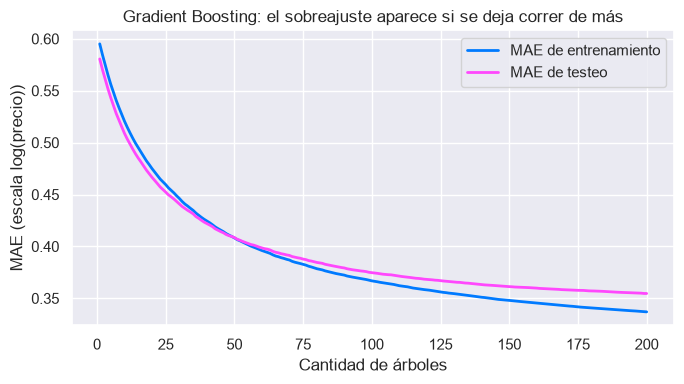

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


In [168]:
# --- 9.2. Gradient Boosting con 200 árboles ---
# Gradient Boosting también construye árboles en secuencia, pero en vez de reponderar
# avisos "difíciles" (como AdaBoost), cada árbol nuevo se entrena para predecir el
# residuo (el error que quedó) del ensamble hasta ese punto — literalmente intenta
# corregir lo que los árboles anteriores dejaron sin explicar. learning_rate=0.05
# achica el aporte de cada árbol nuevo, para que la corrección sea gradual y no
# sobreajuste de golpe.
gb_pipe = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEMILLA,
    )),
])

# evaluar() ya fitea gb_pipe sobre X_train/log(y_train) (además del CV 5-fold);
# reusamos ese mismo fit para el gráfico de staged_predict en vez de fitear dos veces.
historial.append(evaluar("Gradient Boosting", gb_pipe))
guardar_checkpoint("historial", historial)

# staged_predict() es específico de Gradient Boosting: devuelve, uno por uno, cómo
# hubiera predicho el ensamble usando sólo los primeros 1, 2, 3... árboles. Sirve para
# ver la curva de error a medida que se agregan árboles, y así detectar en qué punto
# empieza el sobreajuste (cuando el error de test deja de bajar, o empieza a subir,
# aunque el de train siga bajando). Pipeline no expone staged_predict directamente,
# así que hay que llamarlo sobre el modelo interno con los datos ya preprocesados.
gb_model = gb_pipe.named_steps["model"]
gb_prep = gb_pipe.named_steps["prep"]
X_train_gb = gb_prep.transform(X_train)
X_test_gb = gb_prep.transform(X_test)

mae_train_por_iteracion = np.array([
    mean_absolute_error(np.log(y_train), pred_parcial)
    for pred_parcial in gb_model.staged_predict(X_train_gb)
])
mae_test_por_iteracion = np.array([
    mean_absolute_error(np.log(y_test), pred_parcial)
    for pred_parcial in gb_model.staged_predict(X_test_gb)
])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(mae_train_por_iteracion) + 1), mae_train_por_iteracion,
        color=AZUL, lw=2, label="MAE de entrenamiento")
ax.plot(range(1, len(mae_test_por_iteracion) + 1), mae_test_por_iteracion,
        color=MAGENTA, lw=2, label="MAE de testeo")
ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("MAE (escala log(precio))")
ax.set_title("Gradient Boosting: el sobreajuste aparece si se deja correr de más")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(historial).set_index("modelo").round(3)

In [169]:
# --- 9.3. XGBoost tuneado por Optuna (TPE) ---
# XGBoost es una implementación de Gradient Boosting más regularizada y más rápida, con
# hiperparámetros adicionales para controlar el sobreajuste (reg_lambda, reg_alpha) y
# para introducir aleatoriedad entre árboles (subsample, colsample_bytree), similar en
# espíritu a max_features de Random Forest.
#
# Con 8 hiperparámetros a la vez, una grilla exhaustiva (GridSearchCV) sería
# combinatoriamente enorme. Optuna busca de forma más inteligente: en vez de probar
# todas las combinaciones de una grilla fija, usa optimización bayesiana (TPE,
# Tree-structured Parzen Estimator) para ir eligiendo el próximo punto a probar en base
# a los resultados de los intentos anteriores, concentrando la búsqueda donde parece
# haber mejores configuraciones.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Deteccion de GPU para XGBoost. XGBoost (a diferencia de scikit-learn, que es CPU-only
# y no tiene forma de usar GPU en ningun modelo de este notebook) sabe entrenar arboles
# en GPU si se le pasa device="cuda". Ojo: pedirle device="cuda" a un build de XGBoost
# sin GPU disponible NO tira error -- cae solo a CPU pero imprime un warning por cada
# fit (y aca hay cientos), lo que rompe la regla de "sin warnings". Por eso la deteccion
# se hace antes, mirando si el sistema operativo ve una GPU NVIDIA (con nvidia-smi, el
# comando estandar para eso -- esta en cualquier maquina con drivers NVIDIA instalados,
# incluida cualquier runtime de Colab con GPU elegida) en vez de preguntarle a XGBoost.
def hay_gpu_nvidia():
    if shutil.which("nvidia-smi") is None:
        return False
    try:
        resultado = subprocess.run(["nvidia-smi"], capture_output=True,
                                   timeout=5, check=False)
        return resultado.returncode == 0
    except Exception:
        return False

XGB_DEVICE = "cuda" if hay_gpu_nvidia() else "cpu"
print(f"XGBoost va a entrenar en: {XGB_DEVICE}")

# Kwargs fijos de XGBoost, reusados en 9.3, 9.4 y 10.1 (evita que las tres
# copias diverjan si se toca uno solo). tree_method="hist" es el que soporta GPU;
# en CPU también es el más rápido de los disponibles, así que no hay downside a
# dejarlo fijo independientemente del device.
XGB_FIJOS = dict(
    objective="reg:absoluteerror", random_state=SEMILLA, n_jobs=-1,
    tree_method="hist", device=XGB_DEVICE,
)

# `objective` es la función que Optuna llama en cada intento ("trial"): arma un modelo
# con los hiperparámetros que Optuna eligió para ese trial, lo evalúa por CV 3-fold (3
# en vez de 5 para que cada trial sea más rápido — hay 100 de ellos) y devuelve el error
# a minimizar.
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
    }
    model = Pipeline([
        ("prep", construir_preprocesador()),
        ("model", xgb.XGBRegressor(**params, **XGB_FIJOS)),
    ])
    scores = cross_val_score(
        model, X_train, np.log(y_train),
        cv=3, scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    return -scores.mean()

# Checkpointing: 100 trials x CV 3-fold cada uno, el cuello de botella más grande de
# todo el notebook. Si ya hay un study guardado de una corrida anterior, se reusa entero
# (Optuna guarda todos los trials adentro) y no se vuelve a optimizar.
study = cargar_checkpoint("optuna_study")
if study is not None:
    print("study de Optuna restaurado desde checkpoint, no se reoptimiza")
else:
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEMILLA),
    )
    study.optimize(objective, n_trials=100, show_progress_bar=False)  # 100 intentos
    guardar_checkpoint("optuna_study", study)

print(f"Mejor MAE interno (CV 3-fold, log): {study.best_value:.3f}")
print(f"Mejores hiperparámetros: {study.best_params}")

XGBoost va a entrenar en: cpu
Mejor MAE interno (CV 3-fold, log): 0.343
Mejores hiperparámetros: {'n_estimators': 783, 'learning_rate': 0.05028249547717533, 'max_depth': 7, 'subsample': 0.636052227861582, 'colsample_bytree': 0.675596442564567, 'min_child_weight': 9, 'reg_lambda': 0.6206021233540865, 'reg_alpha': 0.3862856378971199}


In [170]:
# --- 9.4. XGBoost final con los hiperparámetros ganadores ---
# study.best_params tiene la mejor combinación que Optuna encontró; acá se entrena el
# modelo final con esos valores (sin volver a buscar) y se evalúa igual que el resto.
xgb_opt = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", xgb.XGBRegressor(**study.best_params, **XGB_FIJOS)),
])

historial.append(evaluar("XGBoost (Optuna)", xgb_opt))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


AdaBoost cerca de Bagging. Gradient Boosting baja otro escalón bajo Random Forest — `staged_predict` muestra el MAE de test todavía bajando en la iteración 200, sin separarse mucho del de train: margen antes de sobreajustar con `learning_rate=0.05`.

XGBoost/Optuna cierra el piso del trabajo. La ventaja sobre GB de sklearn está en la búsqueda: TPE cubre 8 dimensiones (incluida la regularización L1/L2) que la grilla manual no explora — los valores concretos que encontró están en `study.best_params`, arriba.


---

# 10. Voting y Stacking

Bases "limpias" (sin GridSearchCV adentro): k-NN, árbol podado, Random Forest, XGBoost. SVR afuera — Voting/Stacking clonan y reentrenan cada base en cada fit, y el CV interno de Stacking más el CV externo de `evaluar` multiplican eso ~25×; con SVR la corrida no cierra.

In [171]:
# --- 10.1. Bases "limpias" con los hiperparámetros ganadores ---
# Voting y Stacking (próximas celdas) combinan varios modelos ya entrenados. Para eso no
# hace falta repetir la búsqueda de hiperparámetros de cada uno — se reconstruyen
# versiones "limpias": el mismo modelo y los mismos hiperparámetros ganadores de las
# secciones 5, 7, 8 y 9, pero sin el GridSearchCV/Optuna por dentro (ya se sabe qué
# valores usar).
#
# Nota de runtime: la RF del stacking usa 200 árboles en lugar de los 500 del
# modelo final de 8.3. El StackingRegressor clona cada base y la re-entrena 5 veces
# (cv interno) por cada fold del CV externo de `evaluar` — con 500 árboles la
# corrida se vuelve prohibitiva. 200 árboles mantiene la señal y reduce el costo
# unas 2.5×.
knn_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", KNeighborsRegressor(
        n_neighbors=grid_knn.best_params_["model__n_neighbors"],
        weights=grid_knn.best_params_["model__weights"],
        p=grid_knn.best_params_["model__p"],
    )),
])
arbol_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", DecisionTreeRegressor(
        random_state=SEMILLA, ccp_alpha=alpha_opt_arbol,
    )),
])
rf_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", RandomForestRegressor(
        n_estimators=200, max_features=mejor_frac,
        oob_score=True, random_state=SEMILLA, n_jobs=-1,
    )),
])
xgb_limpio = Pipeline([
    ("prep", construir_preprocesador()),
    ("model", xgb.XGBRegressor(**study.best_params, **XGB_FIJOS)),
])

# Lista de (nombre, pipeline) — el formato que esperan VotingRegressor y
# StackingRegressor.
bases = [("knn", knn_limpio), ("tree", arbol_limpio),
         ("rf", rf_limpio), ("xgb", xgb_limpio)]

In [172]:
# --- 10.2. Voting (promedio de predicciones) ---
# VotingRegressor entrena cada una de las bases por separado y, para predecir, promedia
# sus predicciones individuales. Es el equivalente en regresión al "soft voting" de
# clasificación (que promedia probabilidades en vez de precios).
voting = VotingRegressor(estimators=bases, n_jobs=-1)

historial.append(evaluar("Voting", voting))
guardar_checkpoint("historial", historial)
pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


In [173]:
# --- 10.3. Stacking con meta-Ridge y CV interno 5-fold ---
# StackingRegressor va un paso más allá de Voting: en vez de promediar las bases con el
# mismo peso para todas, entrena un "meta-modelo" (acá, un Ridge simple) que aprende
# cómo combinarlas — qué peso darle a cada una — a partir de sus predicciones. Para que
# el meta-modelo no haga trampa (aprender a confiar en una base sólo porque memorizó
# train), StackingRegressor genera las predicciones con las que entrena al meta-modelo
# usando su propio CV interno (cv=5): cada base predice sobre folds que no vio durante
# su propio entrenamiento.
# Checkpointing: evaluar() sobre Stacking reentrena las 4 bases 6 veces (5-fold CV +
# fit final) más el CV interno del propio StackingRegressor -- la celda más cara de la
# sección 10. Si "Stacking" ya tiene fila en `historial`, se restaura el objeto ya
# entrenado (10.4 lo necesita para leer los coeficientes del meta-modelo) y se saltea
# el reentrenamiento.
if ya_evaluado("Stacking"):
    stacking = cargar_checkpoint("stacking")
    print("Stacking ya evaluado en una corrida anterior, "
          "se restaura el modelo entrenado")
else:
    stacking = StackingRegressor(
        estimators=bases,
        final_estimator=Ridge(alpha=1.0),
        cv=5, n_jobs=-1,
    )
    historial.append(evaluar("Stacking", stacking))
    guardar_checkpoint("stacking", stacking)
    guardar_checkpoint("historial", historial)

pd.DataFrame(historial).set_index("modelo").round(3)

,MAE (BRL),RMSE (BRL),MAPE,R2,MAE (CV),MAE (train)
modelo,,,,,,
Baseline: media,488.950,929.598,1.081,-0.000,NaN,NaN
Baseline: mediana barrio x tipo,396.863,942.708,0.490,-0.029,NaN,NaN
Regresión lineal sobre precio,371.482,719.034,0.705,0.401,368.139,363.170
Regresión lineal sobre log(precio),312.668,845.731,0.411,0.172,293.215,288.513
Ridge,313.020,853.410,0.411,0.157,293.273,288.581
Lasso,312.692,852.093,0.410,0.159,293.375,288.816
k-NN,297.970,712.215,0.400,0.413,297.777,0.000
SVR,284.496,715.359,0.350,0.408,280.523,222.139
Árbol podado,341.961,788.175,0.491,0.281,329.064,324.855


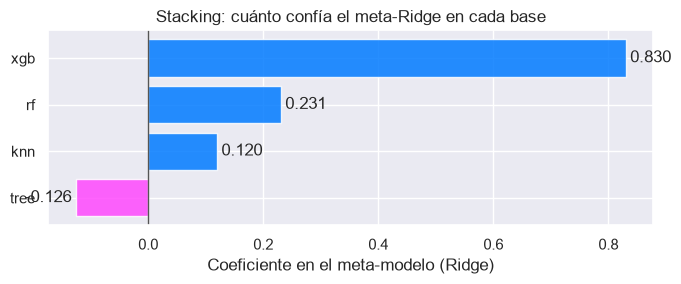

In [174]:
# --- 10.4. Coeficientes del meta-modelo ---
# `stacking` ya quedó entrenado dentro de evaluar() en 10.3 (mismos X_train,
# np.log(y_train)); no hace falta re-fitear el ensamble más caro del cuaderno.
# Los coeficientes del Ridge final (final_estimator_) dicen cuánto peso le dio el
# meta-modelo a la predicción de cada base: un coeficiente alto significa que el
# meta-modelo confía mucho en esa base para el resultado final.
coefs_stacking = pd.Series(
    stacking.final_estimator_.coef_,
    index=[nombre for nombre, _ in stacking.estimators],
).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
colores_coef = [MAGENTA if v < 0 else AZUL for v in coefs_stacking.values]
barras = ax.barh(coefs_stacking.index, coefs_stacking.values,
                 color=colores_coef, alpha=0.85)
ax.bar_label(barras, fmt="%.3f", padding=3)
ax.axvline(0, color=GRIS, linewidth=1)
ax.set_xlabel("Coeficiente en el meta-modelo (Ridge)")
ax.set_title("Stacking: cuánto confía el meta-Ridge en cada base")
plt.tight_layout()
plt.show()


---

# 11. Comparativa final del curso

Todos los modelos juntos: baselines, OLS crudo/log, Ridge, Lasso, 5–9, Voting y Stacking. MAE en BRL, siempre en escala real.

In [175]:
# --- 11.1. Tabla final ---
# df_final junta cada fila que se fue apilando en `historial` a lo largo de todo el
# trabajo (baselines, lineales, no lineales, ensambles) en una sola tabla comparable.
df_final = pd.DataFrame(historial).set_index("modelo").round(3)
df_final = df_final.loc[:, ["MAE (train)", "MAE (CV)", "MAE (BRL)", "RMSE (BRL)",
                              "MAPE", "R2"]]
df_final

,MAE (train),MAE (CV),MAE (BRL),RMSE (BRL),MAPE,R2
modelo,,,,,,
Baseline: media,NaN,NaN,488.950,929.598,1.081,-0.000
Baseline: mediana barrio x tipo,NaN,NaN,396.863,942.708,0.490,-0.029
Regresión lineal sobre precio,363.170,368.139,371.482,719.034,0.705,0.401
Regresión lineal sobre log(precio),288.513,293.215,312.668,845.731,0.411,0.172
Ridge,288.581,293.273,313.020,853.410,0.411,0.157
Lasso,288.816,293.375,312.692,852.093,0.410,0.159
k-NN,0.000,297.777,297.970,712.215,0.400,0.413
SVR,222.139,280.523,284.496,715.359,0.350,0.408
Árbol podado,324.855,329.064,341.961,788.175,0.491,0.281


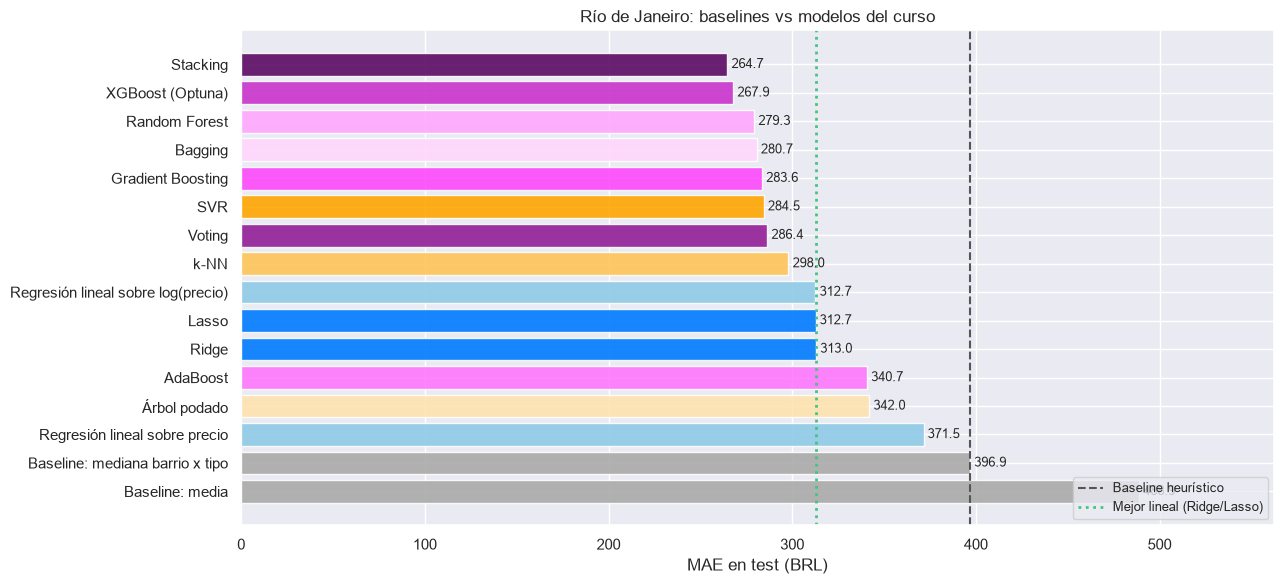

In [176]:
# --- 11.2. Gráfico de barras con MAE de test ordenado ---
# Mismo contenido que la tabla, en formato visual: cada barra es el MAE de test de un
# modelo, ordenadas de peor (arriba) a mejor (abajo). Los colores agrupan por familia de
# modelo, para ver de un vistazo si el error baja al pasar de baselines a lineales a
# árboles a ensambles, sin tener que leer la tabla número por número.
# Paleta agrupada por familia de modelo, no por modelo individual: la versión anterior
# le daba a cada modelo un color más o menos suelto (k-NN en rosa pastel, SVR en verde
# -- el mismo verde que ya usa la línea de referencia del mejor lineal más abajo, lo que
# lo hacía parecer relacionado sin estarlo), así que de un vistazo no se distinguía a
# qué familia pertenecía cada barra. Ahora cada familia tiene un solo matiz base de la
# paleta de la cátedra, y dentro de la familia se generan tonos de ese mismo matiz (de
# claro a oscuro) con LinearSegmentedColormap.from_list -- una interpolación lineal
# entre dos colores en espacio RGB -- en vez de elegir cada tono a mano, así los grados
# de color reflejan progresión real (p.ej. de "modelo simple" a "modelo más sofisticado
# de la misma familia") y no una elección arbitraria:
#   - baselines: gris (BASELINE), sin gradiente porque son sólo puntos de referencia.
#   - lineales: celeste para los dos OLS crudos, azul para los dos regularizados
#     (Ridge/Lasso) -- mismo criterio que ya usa el resto del cuaderno para
#     "antes/después de una mejora" (ver 2.8, 2.10).
#   - no lineales simples (árbol, k-NN, SVR): un solo modelo, no un ensamble -- gama de
#     naranja (NARANJA) de claro a oscuro, en el mismo orden en que aparecen
#     en el texto.
#   - ensambles (Bagging a Stacking): gama de magenta que pasa por el MAGENTA de la
#     cátedra a mitad de camino y termina en un violeta oscuro, ordenada de menos a más
#     sofisticado (promediar árboles independientes → Random Forest → boosting →
#     combinar varias familias en Voting/Stacking) -- con 7 modelos en la familia, dos
#     tonos (claro→oscuro) quedarían casi indistinguibles entre sí; un tercer punto de
#     anclaje en el medio da más rango de color para diferenciarlos.
def gama(colores, n):
    # Interpola n colores a lo largo de una gama que pasa por los tonos de `colores`
    # (2 para un degradé simple claro→oscuro, 3+ para pasar por tonos intermedios).
    # Con n=1 devuelve directamente el último tono (el "de referencia" de la paleta).
    if n == 1:
        return [colores[-1]]
    cmap = LinearSegmentedColormap.from_list("gama", colores)
    return [to_hex(cmap(i / (n - 1))) for i in range(n)]


orden_final = [
    "Baseline: media",
    "Baseline: mediana barrio x tipo",
    "Regresión lineal sobre precio",
    "Regresión lineal sobre log(precio)",
    "Ridge",
    "Lasso",
    "Árbol podado",
    "k-NN",
    "SVR",
    "Bagging",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "XGBoost (Optuna)",
    "Voting",
    "Stacking",
]
colores_final = (
    [BASELINE, BASELINE]                              # baselines
    + [CELESTE, CELESTE, AZUL, AZUL]                  # lineales: crudos, regularizados
    + gama([NARANJA_CLARO, NARANJA], 3)                  # no lineales simples
    + gama([MAGENTA_CLARO, MAGENTA, VIOLETA_OSCURO], 7)  # ensambles
)

mae_plot = df_final.loc[orden_final, "MAE (BRL)"].sort_values(ascending=False)
colores_plot = [colores_final[orden_final.index(m)] for m in mae_plot.index]

fig, ax = plt.subplots(figsize=(13, 6))
barras = ax.barh(mae_plot.index, mae_plot.values, color=colores_plot,
                 alpha=0.9, edgecolor="white")
ax.bar_label(barras, fmt="%.1f", padding=3, fontsize=9)
ax.axvline(df_final.loc["Baseline: mediana barrio x tipo", "MAE (BRL)"],
           color=GRIS, linestyle="--", lw=1.5, label="Baseline heurístico")
ax.axvline(df_final.loc[["Ridge", "Lasso"], "MAE (BRL)"].min(),
           color=VERDE, linestyle=":", lw=2, label="Mejor lineal (Ridge/Lasso)")
ax.set_xlabel("MAE en test (BRL)")
ax.set_xlim(0, mae_plot.max() * 1.15)
ax.set_title("Río de Janeiro: baselines vs modelos del curso")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

1. Familia lineal (OLS, Ridge, Lasso) en una banda estrecha — el techo de la sección 4. La regularización no suma: la multicolinealidad fuerte ya se había resuelto al elegir features en 3.1.

2. Los árboles abren una nueva etapa. El árbol podado apenas se mueve del techo lineal; Bagging y Random Forest bajan el MAE varios BRL — el promedio de árboles decorrelacionados captura lo que uno solo no.

3. Boosting gana: Gradient Boosting y XGBoost/Optuna en el piso del trabajo. Diferencia con Random Forest modesta pero consistente, atribuible al tuneo fino.

4. Voting y Stacking no superan a la mejor base — recombinar no agrega señal cuando el mejor modelo ya toca el techo. El meta-Ridge del stacking pondera fuerte a XGBoost, casi nada al árbol podado.

---

# 12. Conclusiones

El modelo ganador es el de menor MAE en la tabla de la sección 11; las cuatro métricas coinciden en la misma lectura — boosting generaliza donde los lineales no, con mejora clara sobre el baseline heurístico y el techo lineal (Ridge/Lasso).

Features dominantes según RF (impureza y permutación): barrio, tipo de habitación, tamaño (`accommodates`, `bedrooms`, `bathrooms`) y la bandera `sin_reseñas` — las mismas tres familias del EDA (2.6, 2.7, 2.8). El lineal capturaba la dirección pero no la geografía no lineal de los barrios premium.

Limitaciones:

- **Target recortado en el cuantil 99,5 %** (2.5): precio de la oferta típica, no de las propiedades de lujo que dominan los ingresos brutos de Airbnb en Río.
- **Sin componente temporal**: dataset cross-sectional, carnaval pesa igual que marzo.
- **Faltantes de reseñas imputados a cero** (2.6), no a "sin reseñas" — la bandera existe, pero el modelo sigue viendo el cero como valor legítimo de reviews por mes.
- **Grillas recortadas por runtime**: k-NN 64/300 configs, SVR 6/108, `max_features` 19 valores, Optuna 100/200 trials. El techo real podría ser marginalmente mejor con búsquedas más finas; la dirección cualitativa no debería cambiar.

Continuación natural: (1) modelo jerárquico por `room_type` sobre log(precio); (2) features de texto de títulos/descripciones; (3) coordenadas más finas vía clustering sobre latitud/longitud.